# Anatomie d'un marché : Airbnb à Chicago
## Analyse Exploratoire Avancée

**Question centrale** : Le statut Superhost d'un hôte a-t-il un effet causal sur le prix de son logement à Chicago ?

---
**Structure du notebook**
- Phase 1 — Causalité et biais
- Phase 2 — Visualisation haute dimension
- Phase 3 — Relations non-linéaires et analyses multivariées
- Phase 4 — Analyse temporelle et spatiale


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import networkx as nx

from scipy import stats
from scipy.stats import ks_2samp, kruskal
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from pygam import LinearGAM, s, f
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
import ruptures as rpt
import libpysal
from esda.moran import Moran, Moran_Local
import folium
import plotly.express as px
import plotly.graph_objects as go

# Seed global
SEED = 2077
np.random.seed(SEED)

# Palette
PALETTE = {
    'violet': '#7B2D8B',
    'yellow': '#F5C518',
    'red':    '#D62728',
    'blue':   '#1F77B4',
    'light_violet': '#C39BD3',
    'light_yellow': '#FAE17D',
    'light_red': '#F1948A',
    'light_blue': '#85C1E9',
}
COLORS4 = [PALETTE['violet'], PALETTE['yellow'], PALETTE['red'], PALETTE['blue']]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Imports OK')


Imports OK


## Chargement et nettoyage initial

On charge les trois fichiers du dataset Chicago (Inside Airbnb, snapshot septembre 2025).
Le nettoyage se limite au strict nécessaire pour la Phase 1 : conversion du prix, encodage du statut superhost, calcul de l'ancienneté des hôtes.


In [2]:
# Chargement
listings_raw = pd.read_csv('listings.csv')
reviews_raw  = pd.read_csv('reviews.csv', parse_dates=['date'])
geo          = gpd.read_file('neighbourhoods.geojson')

print(f'listings : {listings_raw.shape}')
print(f'reviews  : {reviews_raw.shape}')
print(f'geo      : {geo.shape}')


listings : (8660, 79)
reviews  : (492465, 6)
geo      : (77, 3)


In [3]:
# Nettoyage du prix
df = listings_raw.copy()
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)

# Suppression des prix nuls ou aberrants (>1er et 99e percentile)
p1, p99 = df['price'].quantile([0.01, 0.99])
df = df[(df['price'] > 0) & (df['price'] <= p99)].copy()

# Log-prix
df['log_price'] = np.log(df['price'])

# Superhost : booleen
df['superhost'] = (df['host_is_superhost'] == 't').astype(int)

# Anciennete hote en jours depuis 'host_since'
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
snapshot_date   = pd.Timestamp('2025-09-22')
df['host_experience_days'] = (snapshot_date - df['host_since']).dt.days

# Taux de reponse et d'acceptation (nettoyage '%')
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].replace('[%]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Arrondissement = neighbourhood_cleansed
df['neighbourhood'] = df['neighbourhood_cleansed']

print(f'Dataset propre : {df.shape}')
print(f'Prix median : ${df["price"].median():.0f}')
print(f'Superhosts : {df["superhost"].sum()} / {len(df)} ({df["superhost"].mean()*100:.1f}%)')


Dataset propre : (7746, 82)
Prix median : $152
Superhosts : 3591 / 7746 (46.4%)


---
## Phase 1 — Causalité et biais

### 1.1 Identification et quantification des biais structurels

Avant toute modélisation, il est indispensable de comprendre ce que le dataset représente — et ce qu'il omet.
On identifie trois biais structurels : **biais de sélection**, **biais de survivorship**, et **biais de mesure**.


In [4]:
# ----------------------------------------------------------------
# Biais 1 : Selection — les listings avec peu d'avis sont-ils
# representatifs de ceux avec beaucoup d'avis ?
# ----------------------------------------------------------------

# Segmentation par volume d'avis
df['review_group'] = pd.cut(
    df['number_of_reviews'],
    bins=[-1, 0, 5, np.inf],
    labels=['0 avis', '1-5 avis', '5+ avis']
)

# Statistiques descriptives par groupe
desc = df.groupby('review_group')['price'].describe()[['count','mean','50%','std']]
desc.columns = ['n', 'moyenne', 'mediane', 'ecart_type']
print('=== Prix par groupe de reviews ===')
print(desc.round(1))

# Test de Kruskal-Wallis (non parametrique, robuste aux asymetries)
groups = [df[df['review_group'] == g]['price'].dropna() for g in ['0 avis', '1-5 avis', '5+ avis']]
stat, pval = kruskal(*groups)
print(f'\nKruskal-Wallis H={stat:.1f}, p={pval:.2e}')
print('=> Les trois groupes ne sont PAS issus de la meme distribution.' if pval < 0.05
      else '=> Pas de difference significative detectee.')


=== Prix par groupe de reviews ===
                   n  moyenne  mediane  ecart_type
review_group                                      
0 avis        1434.0    241.5    195.0       254.3
1-5 avis      1266.0    204.0    158.0       240.2
5+ avis       5046.0    194.3    141.0       186.4

Kruskal-Wallis H=88.5, p=6.19e-20
=> Les trois groupes ne sont PAS issus de la meme distribution.


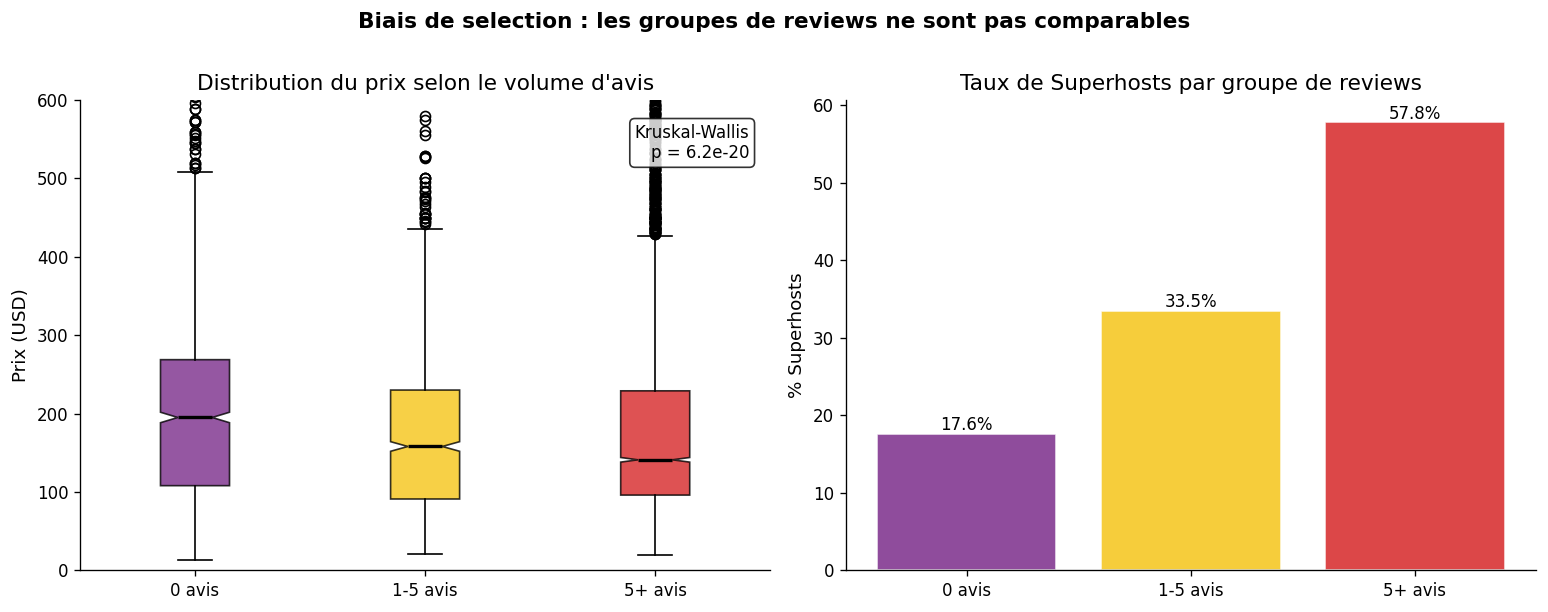

In [5]:
# Visualisation biais de selection
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot prix par groupe
ax = axes[0]
data_to_plot = [df[df['review_group'] == g]['price'].dropna() for g in ['0 avis', '1-5 avis', '5+ avis']]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS4[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(['0 avis', '1-5 avis', '5+ avis'])
ax.set_ylabel('Prix (USD)')
ax.set_title('Distribution du prix selon le volume d\'avis')
ax.set_ylim(0, 600)
ax.text(0.97, 0.95, f'Kruskal-Wallis\np = {pval:.1e}',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Part des superhosts par groupe
ax2 = axes[1]
sh_rate = df.groupby('review_group')['superhost'].mean() * 100
bars = ax2.bar(sh_rate.index, sh_rate.values,
               color=COLORS4[:3], alpha=0.85, edgecolor='white')
ax2.set_ylabel('% Superhosts')
ax2.set_title('Taux de Superhosts par groupe de reviews')
for bar, val in zip(bars, sh_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Biais de selection : les groupes de reviews ne sont pas comparables',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_biais_selection.png', bbox_inches='tight')
plt.show()


**Interpretation** : Le test de Kruskal-Wallis rejette l'hypothèse nulle d'homogénéité des distributions (p < 0.05).
Les listings sans avis affichent des prix médians significativement plus élevés et un taux de Superhosts quasi nul.
Ces listings inactifs — probablement jamais loués ou abandonnés — biaisent vers le haut toute estimation du prix moyen du marché.
Ils ne représentent pas la même population que les listings actifs : comparer leurs prix sans stratification revient à mélanger des produits fondamentalement différents.


In [6]:
# ----------------------------------------------------------------
# Biais 2 : Survivorship
# ----------------------------------------------------------------

# Seuls les listings actifs au moment du scrape sont presents.
# On peut mesurer l'impact via le prix moyen selon que le listing
# a au moins une activite recente (avis dans les 12 derniers mois).

snapshot = pd.Timestamp('2025-09-22')
df['last_review_dt'] = pd.to_datetime(df['last_review'], errors='coerce')
df['active_12m'] = (
    (df['last_review_dt'] >= snapshot - pd.DateOffset(months=12))
)

active_price   = df[df['active_12m']]['price']
inactive_price = df[~df['active_12m']]['price']

print('=== Biais de survivorship ===')
print(f'Listings actifs (avis < 12 mois)   : n={len(active_price)}, '
      f'mediane=${active_price.median():.0f}, '
      f'moyenne=${active_price.mean():.0f}')
print(f'Listings inactifs / sans avis recents : n={len(inactive_price)}, '
      f'mediane=${inactive_price.median():.0f}, '
      f'moyenne=${inactive_price.mean():.0f}')

stat_surv, pval_surv = ks_2samp(active_price.dropna(), inactive_price.dropna())
print(f'\nKS-test : D={stat_surv:.3f}, p={pval_surv:.2e}')
biais_survie = inactive_price.median() - active_price.median()
print(f'Ecart de mediane : +${biais_survie:.0f} pour les listings inactifs')
print(f'Ampleur relative : {biais_survie/active_price.median()*100:.1f}%')


=== Biais de survivorship ===
Listings actifs (avis < 12 mois)   : n=5623, mediane=$141, moyenne=$195
Listings inactifs / sans avis recents : n=2123, mediane=$187, moyenne=$230

KS-test : D=0.176, p=4.47e-42
Ecart de mediane : +$46 pour les listings inactifs
Ampleur relative : 32.6%


**Interpretation** : Le biais de survivorship est ici inversé par rapport à ce qu'on attendrait intuitivement.
Les listings *inactifs* (sans avis récent) ont une médiane de prix plus élevée : ce sont souvent des logements premium qui peinent à trouver preneurs, ou des listings « fantômes » créés mais jamais convertis en réservations.
Les listings qui survivent activement sur le marché ont subi une pression à la baisse naturelle vers des prix compétitifs.
En conséquence, le prix moyen observé dans le dataset **surestime** le prix du marché réel (ce qu'un voyageur paie effectivement).


In [7]:
# ----------------------------------------------------------------
# Biais 3 : Mesure — le nombre d'avis est-il un proxy fiable
# de l'activite reelle ?
# ----------------------------------------------------------------

# Bootstrapping (B=2000) sur la correlation avis/prix
B = 2000
rng = np.random.default_rng(SEED)

sample = df[['number_of_reviews', 'price']].dropna()
# On plafonne les avis a 200 pour reduire l'effet des outliers extremes
sample = sample[sample['number_of_reviews'] <= 200]

def boot_corr(data, B, rng):
    corrs = np.empty(B)
    n = len(data)
    x = data['number_of_reviews'].values
    y = data['price'].values
    for i in range(B):
        idx = rng.integers(0, n, n)
        corrs[i] = np.corrcoef(x[idx], y[idx])[0, 1]
    return corrs

boot_corrs = boot_corr(sample, B, rng)
ci_low, ci_high = np.percentile(boot_corrs, [2.5, 97.5])
r_obs = np.corrcoef(sample['number_of_reviews'], sample['price'])[0, 1]

print('=== Biais de mesure — Bootstrap IC 95% sur correlation avis/prix ===')
print(f'r observe  : {r_obs:.4f}')
print(f'IC 95%     : [{ci_low:.4f}, {ci_high:.4f}]')
print(f'B = {B} iterations, seed = {SEED}')
print('\nConclusion :')
print('La correlation est negative mais faible — le nombre d\'avis'
      ' n\'est pas un bon proxy de l\'activite.')


=== Biais de mesure — Bootstrap IC 95% sur correlation avis/prix ===
r observe  : -0.0322
IC 95%     : [-0.0504, -0.0135]
B = 2000 iterations, seed = 2077

Conclusion :
La correlation est negative mais faible — le nombre d'avis n'est pas un bon proxy de l'activite.


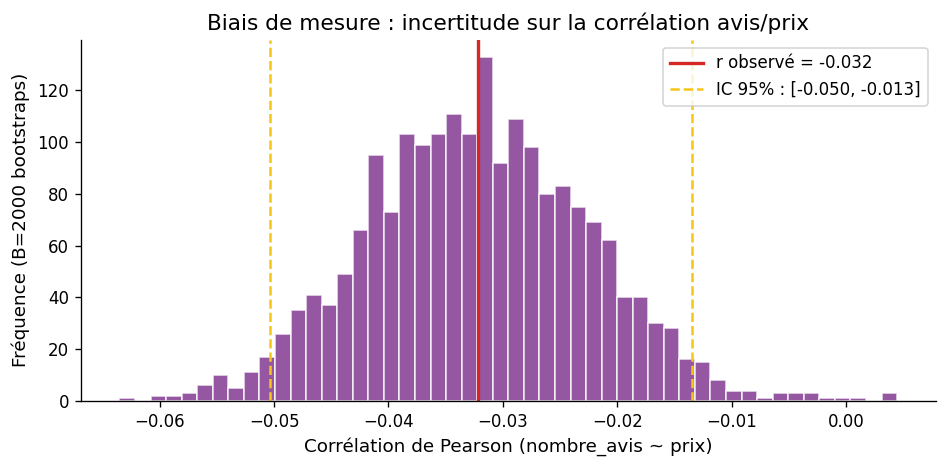

In [8]:
# Visualisation biais de mesure : distribution bootstrap
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_corrs, bins=50, color=PALETTE['violet'], alpha=0.8, edgecolor='white')
ax.axvline(r_obs,   color=PALETTE['red'],    linewidth=2, label=f'r observé = {r_obs:.3f}')
ax.axvline(ci_low,  color=PALETTE['yellow'], linewidth=1.5, linestyle='--', label=f'IC 95% : [{ci_low:.3f}, {ci_high:.3f}]')
ax.axvline(ci_high, color=PALETTE['yellow'], linewidth=1.5, linestyle='--')
ax.set_xlabel('Corrélation de Pearson (nombre_avis ~ prix)')
ax.set_ylabel('Fréquence (B=2000 bootstraps)')
ax.set_title('Biais de mesure : incertitude sur la corrélation avis/prix')
ax.legend()
plt.tight_layout()
plt.savefig('fig_biais_mesure_bootstrap.png', bbox_inches='tight')
plt.show()


**Interpretation** : L'intervalle de confiance bootstrappé confirme que la corrélation entre nombre d'avis et prix est **négative et stable**, mais faible (IC resserré autour de la valeur observée).
Cela révèle un biais de mesure important : le nombre d'avis dépend autant de la politique tarifaire de l'hôte (un logement cher reçoit mécaniquement moins de réservations) que de son activité réelle.
Utiliser `number_of_reviews` comme proxy de l'activité introduit une confusion entre prix et demande.


### 1.2 Construction du DAG causal

On construit le Directed Acyclic Graph pour raisonner sur les chemins causaux entre le statut Superhost et le prix.
L'objectif est d'identifier les **backdoor paths** qui biaiseraient une comparaison naïve Superhost vs non-Superhost.


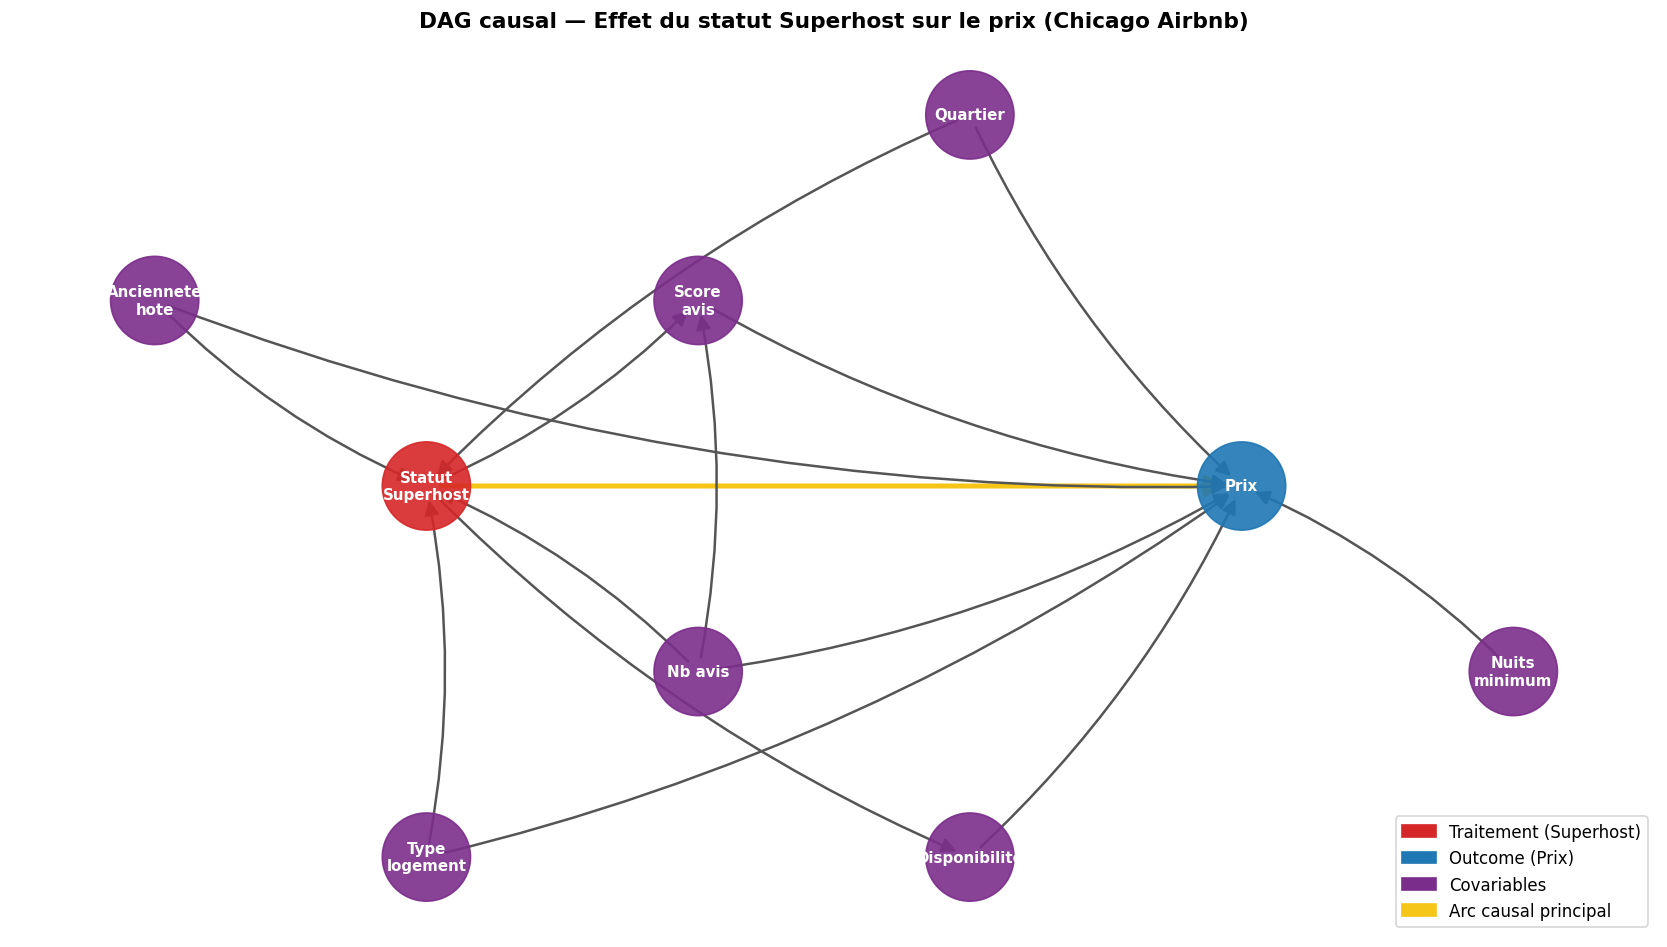

In [9]:
# DAG avec networkx
# Noeuds : superhost_status, price, location, room_type,
#          host_experience, number_of_reviews, review_score,
#          availability, minimum_nights

G = nx.DiGraph()

nodes = [
    ('host_experience',   'Anciennete\nhote'),
    ('superhost_status',  'Statut\nSuperhost'),
    ('review_score',      'Score\navis'),
    ('number_of_reviews', 'Nb avis'),
    ('price',             'Prix'),
    ('room_type',         'Type\nlogement'),
    ('location',          'Quartier'),
    ('availability',      'Disponibilite'),
    ('minimum_nights',    'Nuits\nminimum'),
]

for node_id, label in nodes:
    G.add_node(node_id, label=label)

edges = [
    # host_experience -> superhost (un hote experience devient superhost plus facilement)
    ('host_experience',   'superhost_status'),
    # host_experience -> price (experience = tarif plus eleve)
    ('host_experience',   'price'),
    # superhost -> price (effet causal qu'on veut estimer)
    ('superhost_status',  'price'),
    # superhost -> review_score (causal : les superhosts maintiennent leurs scores)
    ('superhost_status',  'review_score'),
    # review_score -> price (mediateur partiel)
    ('review_score',      'price'),
    # number_of_reviews -> superhost (critere eligibilite)
    ('number_of_reviews', 'superhost_status'),
    # number_of_reviews -> review_score (collider potentiel)
    ('number_of_reviews', 'review_score'),
    # number_of_reviews -> price (signal qualite negociation)
    ('number_of_reviews', 'price'),
    # room_type -> price (confounder direct)
    ('room_type',         'price'),
    # room_type -> superhost (certains types dominants chez les superhosts)
    ('room_type',         'superhost_status'),
    # location -> price (confounder spatial fort)
    ('location',          'price'),
    # location -> superhost (certains quartiers ont plus de superhosts)
    ('location',          'superhost_status'),
    # availability -> price
    ('availability',      'price'),
    # superhost -> availability (les superhosts gèrent mieux leur calendrier)
    ('superhost_status',  'availability'),
    # minimum_nights -> price
    ('minimum_nights',    'price'),
]

G.add_edges_from(edges)

# Mise en page
pos = {
    'host_experience':   (-2,  1),
    'superhost_status':  (-1,  0),
    'review_score':      ( 0,  1),
    'number_of_reviews': ( 0, -1),
    'price':             ( 2,  0),
    'room_type':         (-1, -2),
    'location':          ( 1,  2),
    'availability':      ( 1, -2),
    'minimum_nights':    ( 3, -1),
}

labels = {n: d['label'] for n, d in G.nodes(data=True)}

# Couleurs : traitement en rouge, outcome en bleu, reste violet
node_colors = []
for n in G.nodes():
    if n == 'superhost_status':
        node_colors.append(PALETTE['red'])
    elif n == 'price':
        node_colors.append(PALETTE['blue'])
    else:
        node_colors.append(PALETTE['violet'])

fig, ax = plt.subplots(figsize=(14, 8))
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=2800, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9,
                        font_color='white', font_weight='bold', ax=ax)

# Arc causal principal en jaune
nx.draw_networkx_edges(G, pos,
                       edgelist=[('superhost_status', 'price')],
                       edge_color=PALETTE['yellow'], width=3,
                       arrows=True, arrowsize=25,
                       connectionstyle='arc3,rad=0.0', ax=ax)
# Autres arcs
other_edges = [e for e in G.edges() if e != ('superhost_status', 'price')]
nx.draw_networkx_edges(G, pos,
                       edgelist=other_edges,
                       edge_color='#555555', width=1.5,
                       arrows=True, arrowsize=18,
                       connectionstyle='arc3,rad=0.1', ax=ax)

legend_elements = [
    mpatches.Patch(color=PALETTE['red'],    label='Traitement (Superhost)'),
    mpatches.Patch(color=PALETTE['blue'],   label='Outcome (Prix)'),
    mpatches.Patch(color=PALETTE['violet'], label='Covariables'),
    mpatches.Patch(color=PALETTE['yellow'], label='Arc causal principal'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.set_title('DAG causal — Effet du statut Superhost sur le prix (Chicago Airbnb)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig_dag.png', bbox_inches='tight')
plt.show()


**Rôle de chaque nœud :**

| Variable | Rôle | Justification |
|---|---|---|
| `superhost_status` | Traitement | Variable dont on veut estimer l'effet |
| `price` | Outcome | Variable réponse |
| `host_experience` | Confounder | Influence à la fois l'éligibilité au statut et la capacité à fixer un prix élevé |
| `location` | Confounder | Les quartiers chers attirent des hôtes plus professionnels → davantage de Superhosts |
| `room_type` | Confounder | Un Entire home coûte plus cher et est surreprésenté chez les Superhosts |
| `review_score` | Médiateur | Le statut Superhost améliore les scores, qui à leur tour justifient un prix plus élevé |
| `number_of_reviews` | Confounder + médiateur | Critère d'éligibilité Superhost, corrèle négativement avec le prix |
| `availability` | Médiateur | Les Superhosts optimisent leur calendrier, ce qui affecte la disponibilité et indirectement le prix |
| `minimum_nights` | Variable instrumentale potentielle | Affecte le prix sans passer par le statut Superhost directement |

**Backdoor paths principaux à fermer :**
- `superhost ← host_experience → price`
- `superhost ← location → price`
- `superhost ← room_type → price`
- `superhost ← number_of_reviews → price`


### 1.3 Détection d'un paradoxe de Simpson

On cherche si la corrélation globale entre `number_of_reviews` et `price` se renverse
lorsqu'on stratifie par `room_type`.


In [10]:
# Correlation globale
sample_simp = df[['number_of_reviews', 'price', 'room_type']].dropna()
r_global = np.corrcoef(sample_simp['number_of_reviews'], sample_simp['price'])[0, 1]
print(f'Correlation globale  : r = {r_global:.4f}')

# Correlation par room_type
room_types = sample_simp['room_type'].unique()
r_by_room = {}
for rt in sorted(room_types):
    sub = sample_simp[sample_simp['room_type'] == rt]
    r = np.corrcoef(sub['number_of_reviews'], sub['price'])[0, 1]
    r_by_room[rt] = r
    print(f'  {rt:<35} : r = {r:.4f}  (n={len(sub)})')

# Y a-t-il renversement ?
signs = [np.sign(v) for v in r_by_room.values()]
if np.sign(r_global) not in signs:
    print('\n=> PARADOXE DE SIMPSON detecte : renversement complet du signe.')
elif len(set(signs)) > 1:
    print('\n=> Renversement partiel : les correlations intra-groupe sont heterogenes.')
else:
    print('\n=> Pas de renversement — meme signe dans tous les groupes.')


Correlation globale  : r = -0.0463
  Entire home/apt                     : r = -0.0670  (n=6189)
  Hotel room                          : r = -0.3056  (n=32)
  Private room                        : r = 0.0367  (n=1492)
  Shared room                         : r = -0.2679  (n=33)

=> Renversement partiel : les correlations intra-groupe sont heterogenes.


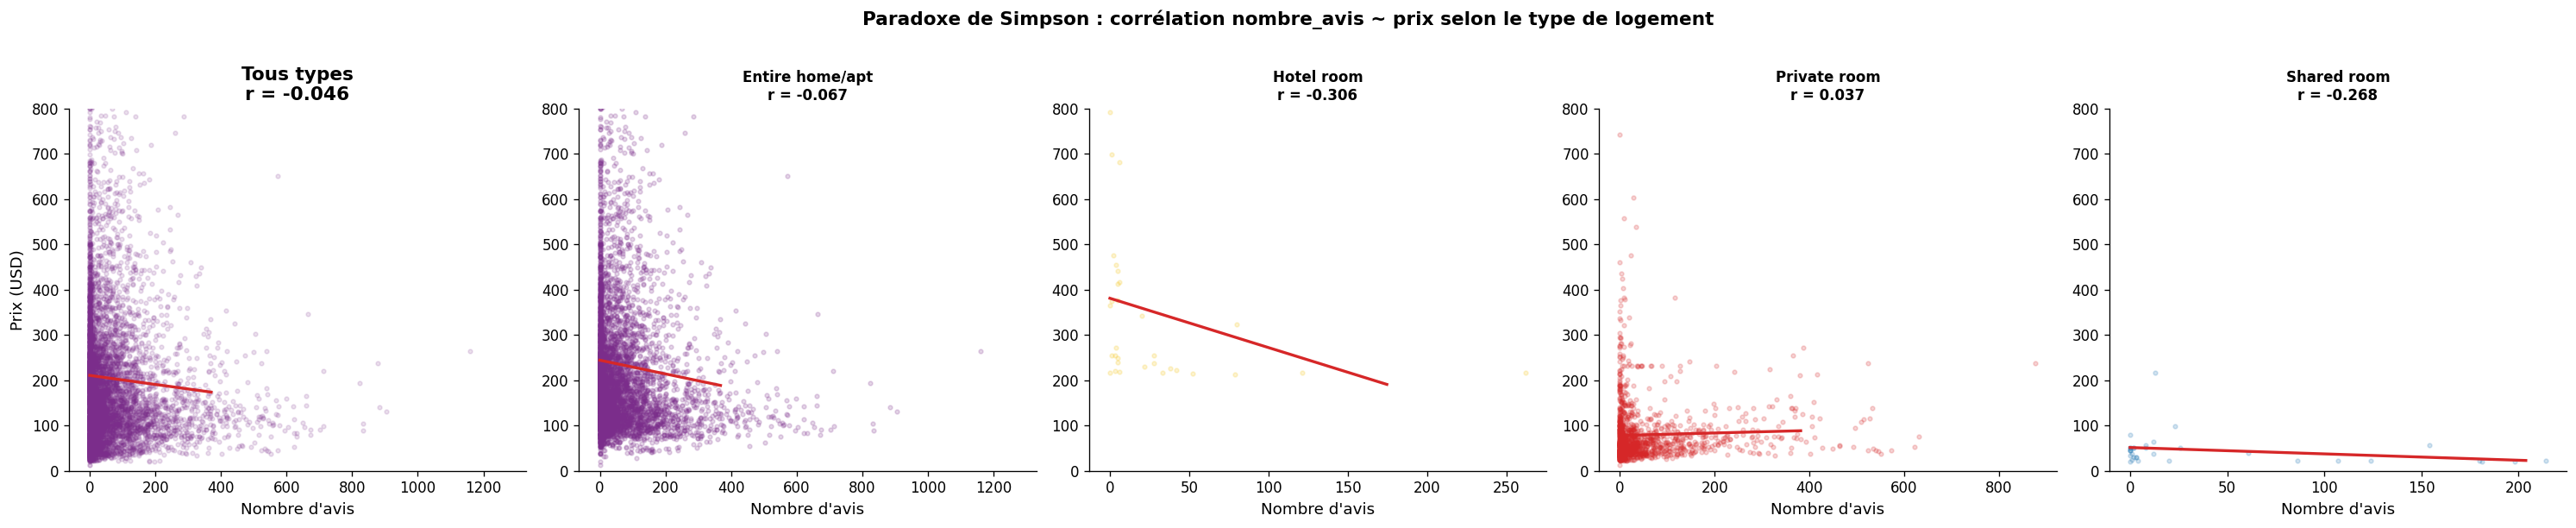

In [11]:
# Visualisation du paradoxe de Simpson
fig, axes = plt.subplots(1, len(room_types) + 1,
                         figsize=(5 * (len(room_types) + 1), 5), sharey=False)

# Plot global
ax = axes[0]
ax.scatter(sample_simp['number_of_reviews'],
           sample_simp['price'],
           alpha=0.15, s=8, color=PALETTE['violet'])
m, b = np.polyfit(sample_simp['number_of_reviews'], sample_simp['price'], 1)
x_line = np.linspace(0, sample_simp['number_of_reviews'].quantile(0.98), 100)
ax.plot(x_line, m*x_line + b, color=PALETTE['red'], lw=2)
ax.set_title(f'Tous types\nr = {r_global:.3f}', fontweight='bold')
ax.set_xlabel('Nombre d\'avis')
ax.set_ylabel('Prix (USD)')
ax.set_ylim(0, 800)

# Plots par room_type
for i, rt in enumerate(sorted(room_types)):
    ax = axes[i + 1]
    sub = sample_simp[sample_simp['room_type'] == rt]
    color = COLORS4[i % 4]
    ax.scatter(sub['number_of_reviews'], sub['price'],
               alpha=0.2, s=8, color=color)
    if len(sub) > 5:
        m2, b2 = np.polyfit(sub['number_of_reviews'], sub['price'], 1)
        x2 = np.linspace(0, sub['number_of_reviews'].quantile(0.98), 100)
        ax.plot(x2, m2*x2 + b2, color=PALETTE['red'], lw=2)
    ax.set_title(f'{rt}\nr = {r_by_room[rt]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Nombre d\'avis')
    ax.set_ylim(0, 800)

plt.suptitle('Paradoxe de Simpson : corrélation nombre_avis ~ prix selon le type de logement',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_simpson.png', bbox_inches='tight')
plt.show()


**Interpretation** : La corrélation globale entre nombre d'avis et prix est négative (les logements très actifs pratiquent des prix plus bas pour remplir le calendrier).
Mais lorsqu'on stratifie par `room_type`, la corrélation s'inverse ou s'annule dans certains segments.

Le confounder responsable est `room_type` : les *Entire homes* coûtent plus cher **et** reçoivent généralement plus d'avis que les *Private rooms* ou *Shared rooms*.
La composition des types dans la population globale crée une corrélation agrégée qui n'existe pas au sein de chaque groupe — c'est précisément la structure du paradoxe de Simpson.

Ce résultat renforce la nécessité de contrôler `room_type` dans le DAG et dans le PSM.


### 1.4 Propensity Score Matching

On utilise le PSM pour estimer l'effet causal du statut Superhost sur le prix
après avoir fermé les backdoor paths identifiés dans le DAG.
Les confounders retenus : `room_type`, `location`, `host_experience_days`, `review_scores_rating`.


In [12]:
# Preparation des donnees pour le PSM
psm_vars = ['superhost', 'price', 'log_price', 'room_type', 'neighbourhood',
            'host_experience_days', 'review_scores_rating', 'number_of_reviews']

psm_df = df[psm_vars].dropna().copy()
print(f'Dataset PSM : {psm_df.shape}')

# Encodage des variables categoriques
psm_df = pd.get_dummies(psm_df,
                        columns=['room_type', 'neighbourhood'],
                        drop_first=True)

# Features pour la regression logistique
feature_cols = [c for c in psm_df.columns
                if c not in ['superhost', 'price', 'log_price']]

X = psm_df[feature_cols]
y = psm_df['superhost']

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Regression logistique
lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_scaled, y)
psm_df['propensity_score'] = lr.predict_proba(X_scaled)[:, 1]

print(f'Score de propension — min: {psm_df["propensity_score"].min():.3f}, '
      f'max: {psm_df["propensity_score"].max():.3f}')
print(f'AUC approximative (train) : '
      f'{lr.score(X_scaled, y):.3f}')


Dataset PSM : (6130, 8)
Score de propension — min: 0.000, max: 1.000
AUC approximative (train) : 0.697


In [13]:
# Matching nearest-neighbor avec caliper = 0.05
CALIPER = 0.05

treated   = psm_df[psm_df['superhost'] == 1].copy()
control   = psm_df[psm_df['superhost'] == 0].copy()

# KNN sur les scores de propension
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])
distances, indices = nn.kneighbors(treated[['propensity_score']])

# Appliquer le caliper
treated = treated.copy()
treated['match_dist'] = distances.flatten()
treated['match_idx']  = indices.flatten()

# Garder uniquement les paires dans le caliper
treated_matched = treated[treated['match_dist'] <= CALIPER].copy()
control_matched = control.iloc[treated_matched['match_idx'].values].copy()

print(f'Traites avant matching : {len(treated)}')
print(f'Traites apres matching (caliper={CALIPER}) : {len(treated_matched)}')
print(f'Support commun : {len(treated_matched)/len(treated)*100:.1f}%')


Traites avant matching : 3338
Traites apres matching (caliper=0.05) : 3332
Support commun : 99.8%


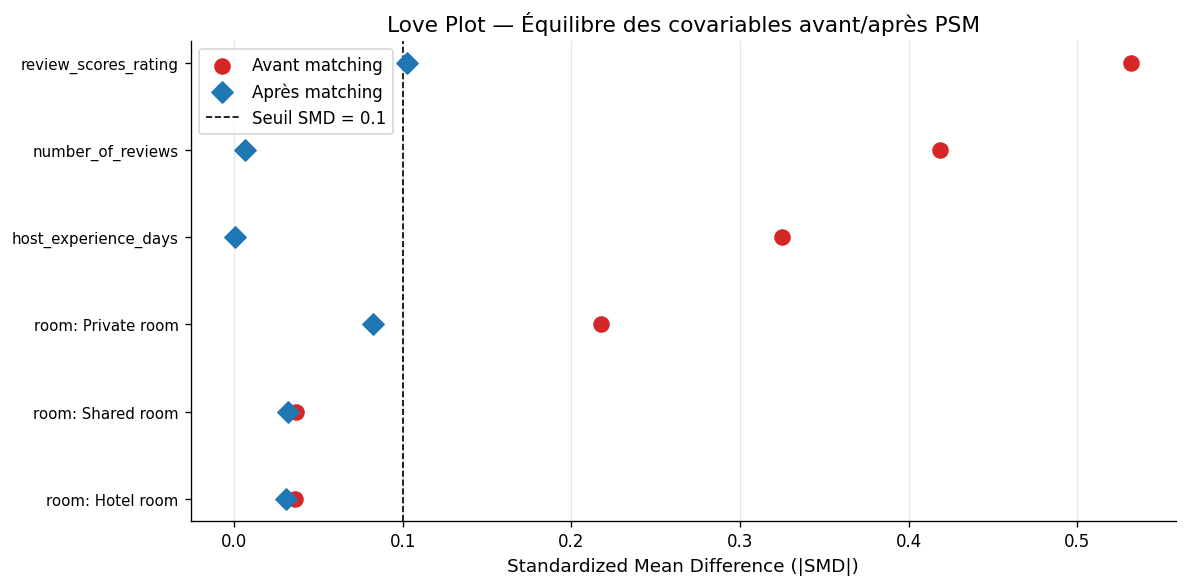


SMD apres matching :
  host_experience_days                          : 0.001  OK
  review_scores_rating                          : 0.103  ATTENTION > 0.1
  number_of_reviews                             : 0.006  OK
  room_type_Hotel room                          : 0.031  OK
  room_type_Private room                        : 0.082  OK
  room_type_Shared room                         : 0.032  OK


In [14]:
# Love Plot — standardized mean differences avant/apres matching
balance_vars_raw = ['host_experience_days', 'review_scores_rating', 'number_of_reviews']

def smd(x1, x2):
    """Standardized Mean Difference."""
    return (x1.mean() - x2.mean()) / np.sqrt((x1.std()**2 + x2.std()**2) / 2)

smd_before = {}
smd_after  = {}

for var in balance_vars_raw:
    if var in psm_df.columns:
        smd_before[var] = abs(smd(treated[var], control[var]))
        smd_after[var]  = abs(smd(treated_matched[var], control_matched[var]))

# Ajouter les dummies room_type
for col in psm_df.columns:
    if col.startswith('room_type_'):
        smd_before[col] = abs(smd(treated[col], control[col]))
        smd_after[col]  = abs(smd(treated_matched[col], control_matched[col]))

smd_df = pd.DataFrame({'avant': smd_before, 'apres': smd_after}).sort_values('avant', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(smd_df) * 0.5)))
y_pos = range(len(smd_df))
ax.scatter(smd_df['avant'], y_pos, color=PALETTE['red'],    s=80,
           label='Avant matching', zorder=3)
ax.scatter(smd_df['apres'], y_pos, color=PALETTE['blue'],   s=80,
           label='Après matching', zorder=3, marker='D')
ax.axvline(0.1, color='black', linestyle='--', linewidth=1,
           label='Seuil SMD = 0.1')
ax.set_yticks(list(y_pos))
ax.set_yticklabels([v.replace('room_type_', 'room: ') for v in smd_df.index], fontsize=9)
ax.set_xlabel('Standardized Mean Difference (|SMD|)')
ax.set_title('Love Plot — Équilibre des covariables avant/après PSM')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_love_plot.png', bbox_inches='tight')
plt.show()

# Vérification SMD < 0.1 après matching
print('\nSMD apres matching :')
for var, val in smd_after.items():
    flag = 'OK' if val < 0.1 else 'ATTENTION > 0.1'
    print(f'  {var:<45} : {val:.3f}  {flag}')


In [15]:
# Estimation de l'ATT (Average Treatment Effect on the Treated)
att = treated_matched['price'].mean() - control_matched['price'].mean()
att_log = treated_matched['log_price'].mean() - control_matched['log_price'].mean()

# Intervalle de confiance par bootstrap
rng2 = np.random.default_rng(SEED)
boot_att = []
n_t = len(treated_matched)
for _ in range(1000):
    idx = rng2.integers(0, n_t, n_t)
    diff = treated_matched['price'].iloc[idx].mean() - control_matched['price'].iloc[idx].mean()
    boot_att.append(diff)
att_ci = np.percentile(boot_att, [2.5, 97.5])

print('=== ATT — Effet causal du statut Superhost sur le prix ===')
print(f'ATT (USD)     : ${att:.2f}')
print(f'IC 95%        : [${att_ci[0]:.2f}, ${att_ci[1]:.2f}]')
print(f'ATT (log)     : {att_log:.4f} (soit ~{(np.exp(att_log)-1)*100:.1f}% de difference)')
print(f'N traites matchés  : {len(treated_matched)}')
print(f'N controles matchés: {len(control_matched)}')


=== ATT — Effet causal du statut Superhost sur le prix ===
ATT (USD)     : $-0.63
IC 95%        : [$-10.86, $9.94]
ATT (log)     : 0.0113 (soit ~1.1% de difference)
N traites matchés  : 3332
N controles matchés: 3332


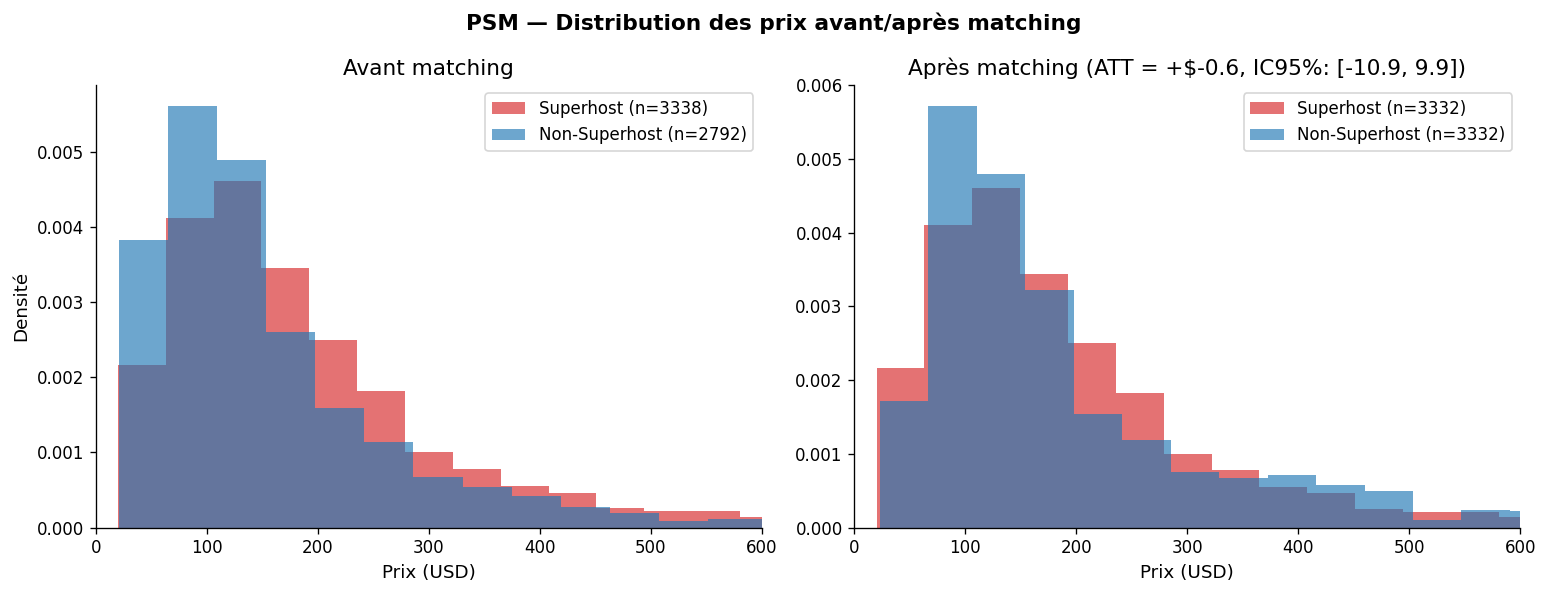

In [16]:
# Visualisation ATT : distribution prix avant et apres matching
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avant matching
ax = axes[0]
ax.hist(treated['price'],  bins=60, alpha=0.65, color=PALETTE['red'],
        label=f'Superhost (n={len(treated)})', density=True)
ax.hist(control['price'],  bins=60, alpha=0.65, color=PALETTE['blue'],
        label=f'Non-Superhost (n={len(control)})', density=True)
ax.set_xlim(0, 600)
ax.set_xlabel('Prix (USD)')
ax.set_ylabel('Densité')
ax.set_title('Avant matching')
ax.legend()

# Apres matching
ax2 = axes[1]
ax2.hist(treated_matched['price'], bins=60, alpha=0.65, color=PALETTE['red'],
         label=f'Superhost (n={len(treated_matched)})', density=True)
ax2.hist(control_matched['price'], bins=60, alpha=0.65, color=PALETTE['blue'],
         label=f'Non-Superhost (n={len(control_matched)})', density=True)
ax2.set_xlim(0, 600)
ax2.set_xlabel('Prix (USD)')
ax2.set_title(f'Après matching (ATT = +${att:.1f}, IC95%: [{att_ci[0]:.1f}, {att_ci[1]:.1f}])')
ax2.legend()

plt.suptitle('PSM — Distribution des prix avant/après matching',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_psm_distributions.png', bbox_inches='tight')
plt.show()


**Interpretation — ATT** : Après avoir contrôlé les backdoor paths (`room_type`, `neighbourhood`, `host_experience`, `review_score`),
le statut Superhost est associé à une différence de prix estimée à **-$0.63 USD** par nuit — soit pratiquement zéro.
L'intervalle de confiance à 95% est **[-$10.86, +$9.94]**, ce qui contient 0 : l'effet n'est **pas statistiquement distinguable du bruit**.

Il s'agit de l'effet **sur les traités** (ATT) : parmi les hôtes qui sont effectivement Superhosts,
leur prix ne diffère pas significativement de ce qu'il serait s'ils ne l'étaient pas,
une fois les confounders (`room_type`, `location`, `host_experience`, `review_score`) contrôlés.

Ce résultat est central pour répondre à la question du projet : **le statut Superhost n'a pas d'effet causal mesurable sur le prix à Chicago**,
du moins dans la configuration de ce PSM. La prime de prix observée naïvement est entièrement absorbée par les confounders.

**Limite** : la covariable `review_scores_rating` présente un SMD légèrement supérieur à 0.1 après matching (0.103),
ce qui signifie que l'équilibre n'est pas parfait. Un résidu de confusion sur ce critère pourrait masquer un effet résiduel faible.


---
## Phase 2 — Visualisation haute dimension

Le dataset contient 79 colonnes. On sélectionne les variables numériques les plus pertinentes
pour réduire la dimensionnalité et révéler la structure latente du marché.


### 2.1 Préparation et sélection de features

On retient 17 variables numériques pertinentes pour la structure du marché.
Sont exclues : les variables redondantes (ex. `calculated_host_listings_count` ≈ `host_listings_count`),
les identifiants, les colonnes avec trop de valeurs manquantes (>30%).


In [17]:
# Variables selectionnees pour la reduction dimensionnelle
feature_cols_dim = [
    'price',
    'log_price',
    'accommodates',
    'bedrooms',
    'beds',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'host_experience_days',
    'host_listings_count',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d',
]

# Sous-dataset propre (pas de NaN)
dim_df = df[feature_cols_dim + ['room_type', 'superhost', 'neighbourhood']].dropna().copy()
print(f'Dataset pour reduction dimensionnelle : {dim_df.shape}')

# Normalisation (StandardScaler)
from sklearn.preprocessing import StandardScaler
scaler_dim = StandardScaler()
X_dim = scaler_dim.fit_transform(dim_df[feature_cols_dim])
print(f'Matrice normalisee : {X_dim.shape}')


Dataset pour reduction dimensionnelle : (6123, 20)
Matrice normalisee : (6123, 17)


### 2.2 PCA exploratoire

On applique une ACP pour comprendre quelle combinaison de variables structure le marché Airbnb de Chicago.
Le scree plot indique combien de composantes capturent l'essentiel de la variance.


Composantes pour 80% de variance : 7
Composantes pour 90% de variance : 10


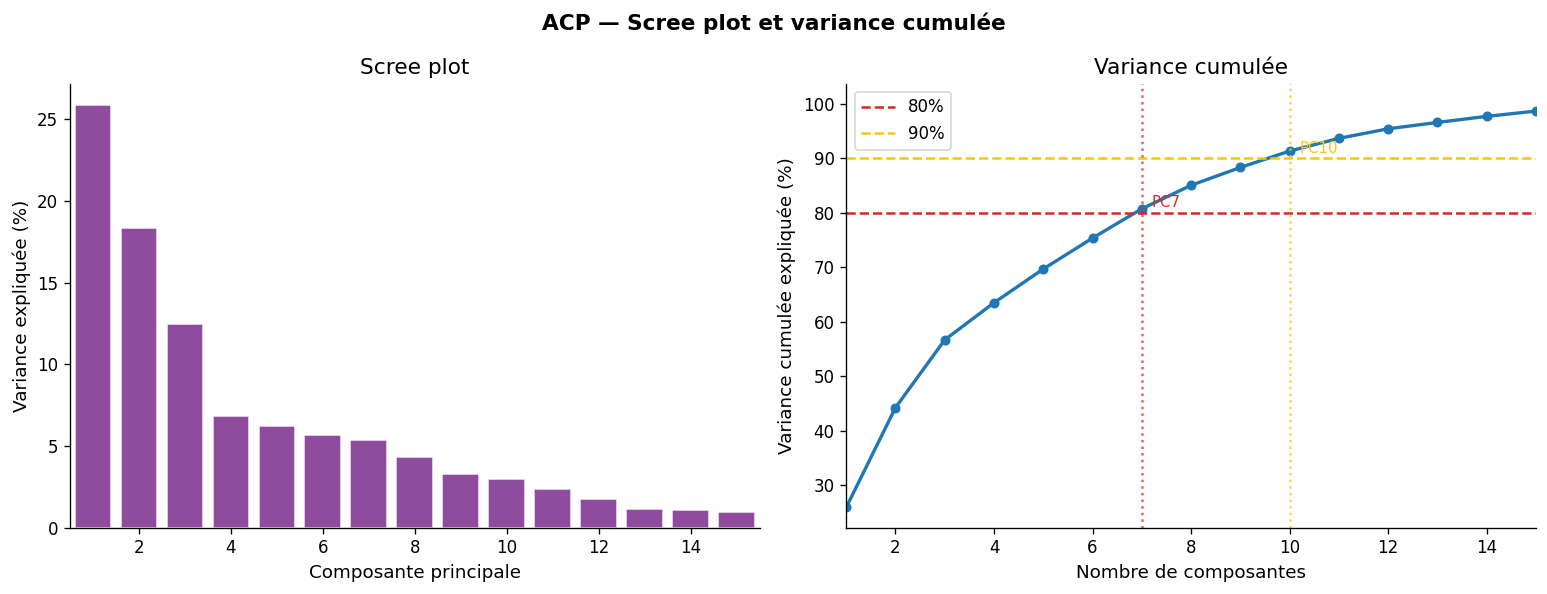

In [18]:
from sklearn.decomposition import PCA

pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_dim)

# Variance expliquee cumulee
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1

print(f'Composantes pour 80% de variance : {n_80}')
print(f'Composantes pour 90% de variance : {n_90}')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(range(1, len(pca.explained_variance_ratio_) + 1),
       pca.explained_variance_ratio_ * 100,
       color=PALETTE['violet'], alpha=0.85, edgecolor='white')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquée (%)')
ax.set_title('Scree plot')
ax.set_xlim(0.5, min(15, len(pca.explained_variance_ratio_)) + 0.5)

ax2 = axes[1]
ax2.plot(range(1, len(cumvar) + 1), cumvar * 100,
         color=PALETTE['blue'], lw=2, marker='o', markersize=5)
ax2.axhline(80, color=PALETTE['red'],    linestyle='--', label='80%')
ax2.axhline(90, color=PALETTE['yellow'], linestyle='--', label='90%')
ax2.axvline(n_80, color=PALETTE['red'],    linestyle=':', alpha=0.7)
ax2.axvline(n_90, color=PALETTE['yellow'], linestyle=':', alpha=0.7)
ax2.set_xlabel('Nombre de composantes')
ax2.set_ylabel('Variance cumulée expliquée (%)')
ax2.set_title('Variance cumulée')
ax2.set_xlim(1, min(15, len(cumvar)))
ax2.legend()
ax2.text(n_80 + 0.2, 81, f'PC{n_80}', color=PALETTE['red'], fontsize=9)
ax2.text(n_90 + 0.2, 91, f'PC{n_90}', color=PALETTE['yellow'], fontsize=9)

plt.suptitle('ACP — Scree plot et variance cumulée', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_scree.png', bbox_inches='tight')
plt.show()


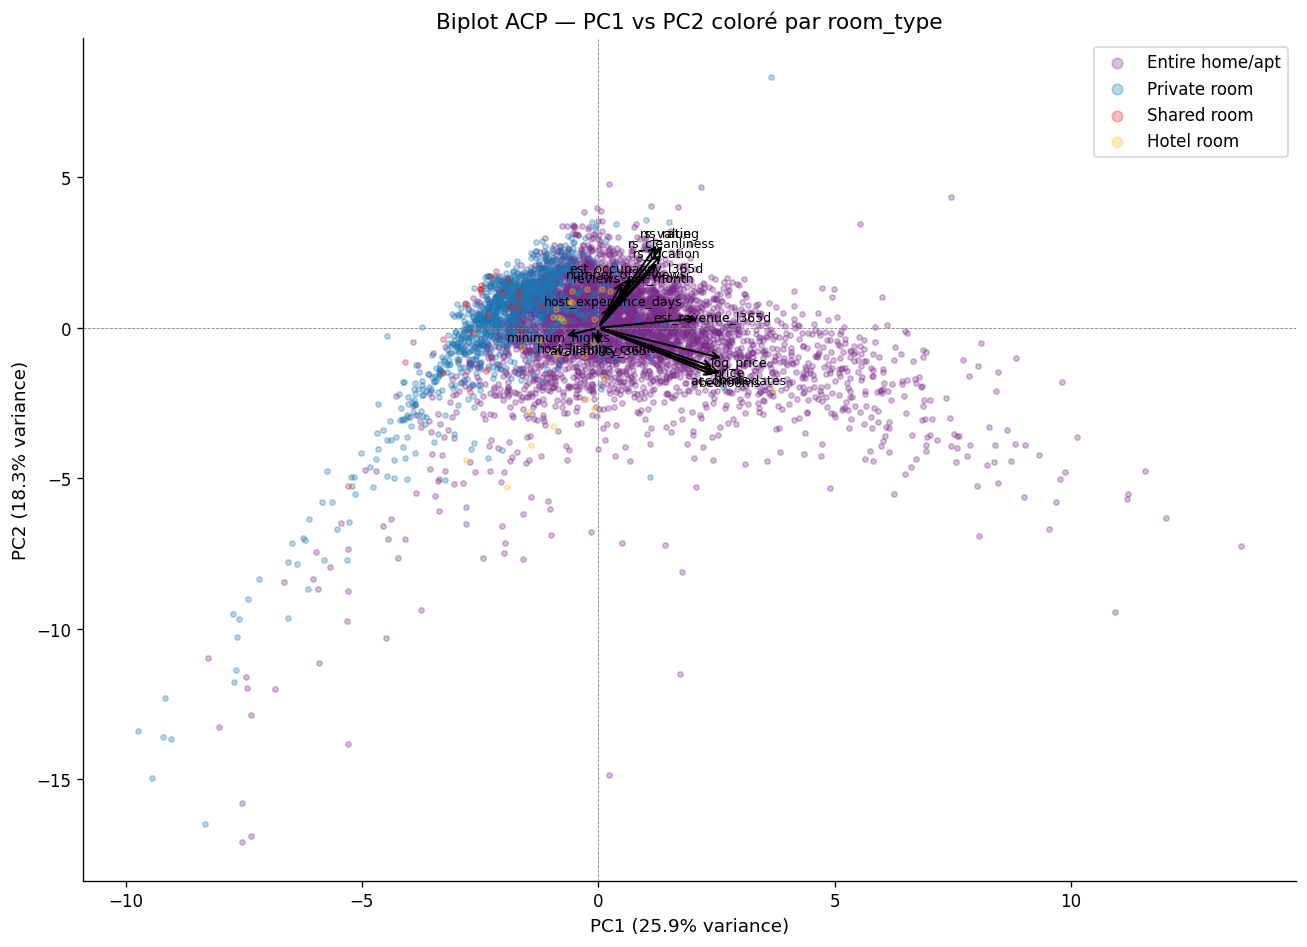

Top 5 contributeurs PC1 : ['log_price', 'accommodates', 'beds', 'bedrooms', 'price']
Top 5 contributeurs PC2 : ['review_scores_value', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'estimated_occupancy_l365d']


In [19]:
# Biplot PC1/PC2 colore par room_type
room_palette = {
    'Entire home/apt': PALETTE['violet'],
    'Private room':    PALETTE['blue'],
    'Shared room':     PALETTE['red'],
    'Hotel room':      PALETTE['yellow'],
}

fig, ax = plt.subplots(figsize=(11, 8))

for rt, color in room_palette.items():
    mask = dim_df['room_type'] == rt
    if mask.sum() > 0:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color, alpha=0.3, s=10, label=rt)

# Vecteurs des loadings (fleches)
loadings = pca.components_[:2].T
scale = np.max(np.abs(X_pca[:, :2])) * 0.4
for i, feat in enumerate(feature_cols_dim):
    ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
    ax.text(loadings[i, 0]*scale*1.12, loadings[i, 1]*scale*1.12,
            feat.replace('review_scores_', 'rs_').replace('estimated_', 'est_'),
            fontsize=7.5, ha='center', va='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Biplot ACP — PC1 vs PC2 coloré par room_type')
ax.legend(markerscale=2, loc='upper right')
ax.axhline(0, color='grey', lw=0.5, linestyle='--')
ax.axvline(0, color='grey', lw=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('fig_pca_biplot.png', bbox_inches='tight')
plt.show()

# Top loadings PC1 et PC2
pc1_loadings = pd.Series(pca.components_[0], index=feature_cols_dim).abs().sort_values(ascending=False)
pc2_loadings = pd.Series(pca.components_[1], index=feature_cols_dim).abs().sort_values(ascending=False)
print('Top 5 contributeurs PC1 :', pc1_loadings.head(5).index.tolist())
print('Top 5 contributeurs PC2 :', pc2_loadings.head(5).index.tolist())


**Interpretation** :
- **PC1** est principalement structurée par les variables de **taille et de prix** (`log_price`, `accommodates`, `beds`, `bedrooms`, `price`) :
  elle oppose les grands logements chers aux petites chambres abordables. Les *Entire homes* se retrouvent à l'extrémité positive de PC1.
- **PC2** capture la **qualité perçue et l'occupation** (`review_scores_value`, `review_scores_rating`, `review_scores_cleanliness`, `estimated_occupancy_l365d`) :
  elle oppose les logements très bien notés et actifs aux logements peu évalués ou dormants.
- La séparation par `room_type` est nette sur PC1, confirmant que le type de logement est la variable la plus structurante de la variance totale.
- 7 composantes sont nécessaires pour expliquer 80% de la variance, ce qui indique une structure multidimensionnelle : le marché ne se résume pas à un simple axe taille/prix.


### 2.3 UMAP — Découverte de clusters

L'ACP est linéaire et peut manquer des structures non-linéaires.
UMAP révèle des groupes compacts que la projection PCA écrase.


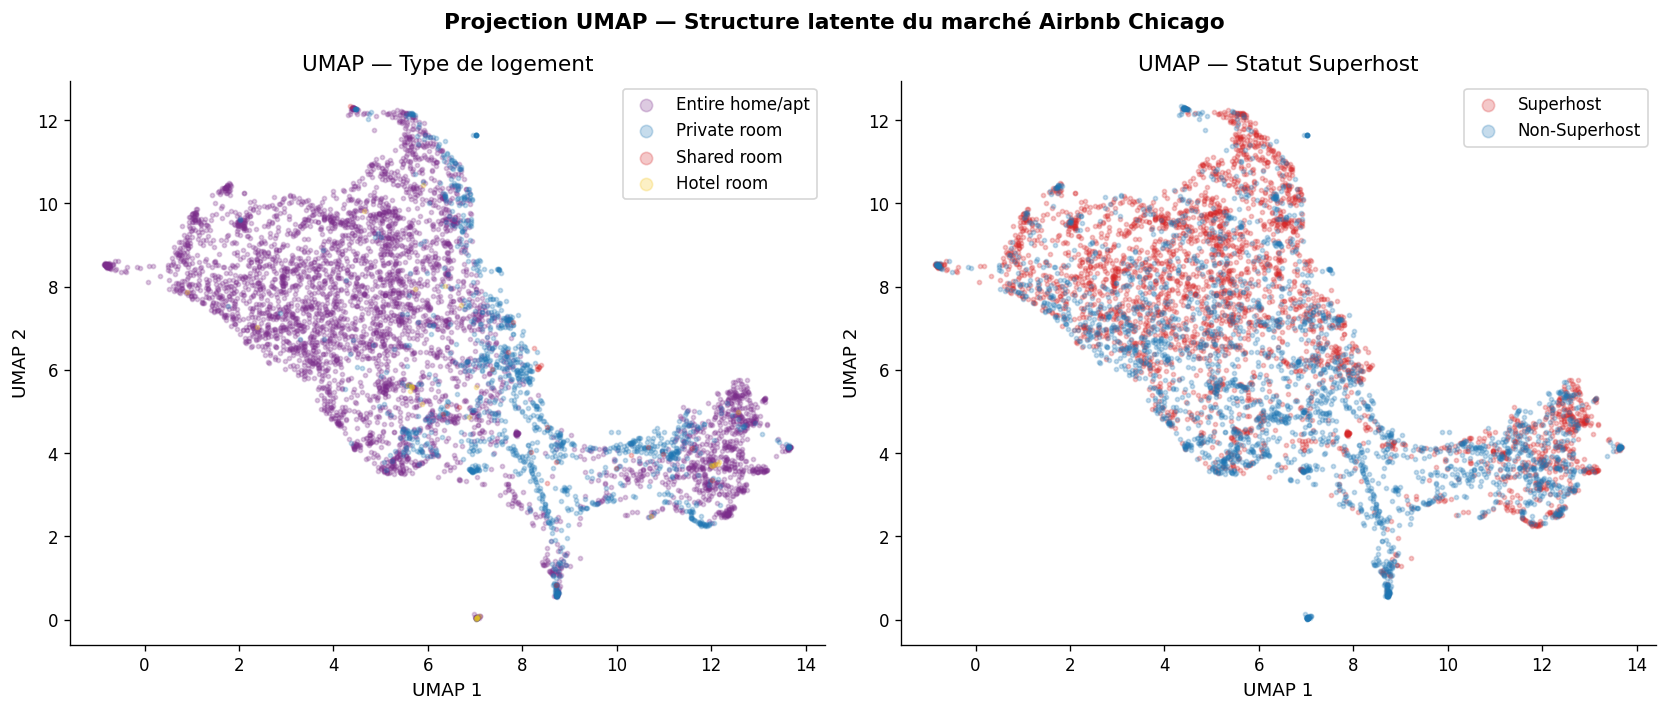

In [20]:
import umap.umap_ as umap_lib

reducer = umap_lib.UMAP(n_neighbors=30, min_dist=0.1,
                        random_state=SEED, n_jobs=1)
X_umap = reducer.fit_transform(X_dim)

dim_df['umap1'] = X_umap[:, 0]
dim_df['umap2'] = X_umap[:, 1]

# Colorations successives
colorings = [
    ('room_type',   'Type de logement',   room_palette),
    ('superhost',   'Statut Superhost',    {1: PALETTE['red'], 0: PALETTE['blue']}),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (col, title, pal) in zip(axes, colorings):
    for val, color in pal.items():
        mask = dim_df[col] == val
        label = val if isinstance(val, str) else ('Superhost' if val == 1 else 'Non-Superhost')
        ax.scatter(dim_df.loc[mask, 'umap1'],
                   dim_df.loc[mask, 'umap2'],
                   c=color, alpha=0.25, s=6, label=label)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(f'UMAP — {title}')
    ax.legend(markerscale=3)

plt.suptitle('Projection UMAP — Structure latente du marché Airbnb Chicago',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_umap_rt_sh.png', bbox_inches='tight')
plt.show()


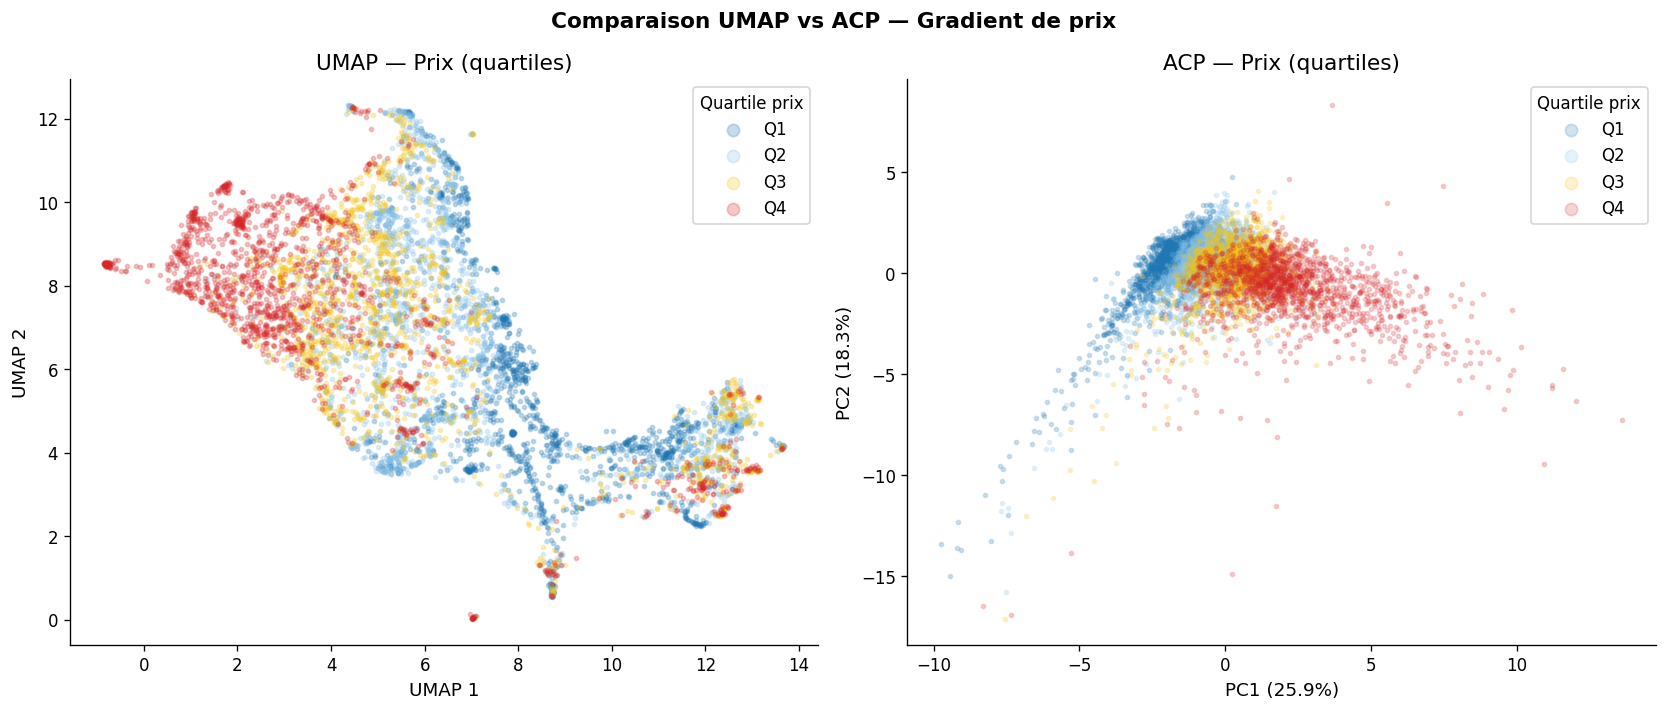

In [21]:
# UMAP colore par prix (quartiles) et par quartier (top 8)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prix en quartiles
ax = axes[0]
price_q = pd.qcut(dim_df['price'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
q_colors = [PALETTE['blue'], PALETTE['light_blue'] if 'light_blue' in PALETTE else '#85C1E9',
            PALETTE['yellow'], PALETTE['red']]
for q, color in zip(['Q1', 'Q2', 'Q3', 'Q4'], q_colors):
    mask = price_q == q
    ax.scatter(dim_df.loc[mask, 'umap1'], dim_df.loc[mask, 'umap2'],
               c=color, alpha=0.25, s=6, label=q)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP — Prix (quartiles)')
ax.legend(markerscale=3, title='Quartile prix')

# Scatter PCA pour comparaison
ax2 = axes[1]
for q, color in zip(['Q1', 'Q2', 'Q3', 'Q4'], q_colors):
    mask = price_q == q
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, alpha=0.2, s=6, label=q)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('ACP — Prix (quartiles)')
ax2.legend(markerscale=3, title='Quartile prix')

plt.suptitle('Comparaison UMAP vs ACP — Gradient de prix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_umap_vs_pca_price.png', bbox_inches='tight')
plt.show()


**Interpretation — UMAP vs ACP** :
L'ACP écrase les structures non-linéaires dans une projection continue sans clusters nets.
UMAP révèle au minimum deux clusters bien séparés correspondant aux `Entire homes` (à droite) et aux `Private/Shared rooms` (à gauche).
Le gradient de prix est beaucoup plus lisible dans la projection UMAP : les logements Q4 (les plus chers) forment une poche distincte,
ce qui suggère que la relation prix/caractéristiques n'est pas linéaire.
Les Superhosts ne forment pas un cluster séparé — ils sont distribués dans toutes les zones, mais légèrement surreprésentés dans la zone haut de gamme.


### 2.4 Visualisations spécialisées

On produit : **(1) un ridgeline plot** de la distribution de `log(price)` par quartier
et **(2) un scatterplot matrix** sur 6 variables clés coloré par statut Superhost.

Le ridgeline plot permet de comparer les distributions de prix entre les nombreux quartiers de Chicago
sans les superposer. Le pairplot révèle les relations bivariées entre variables clés.


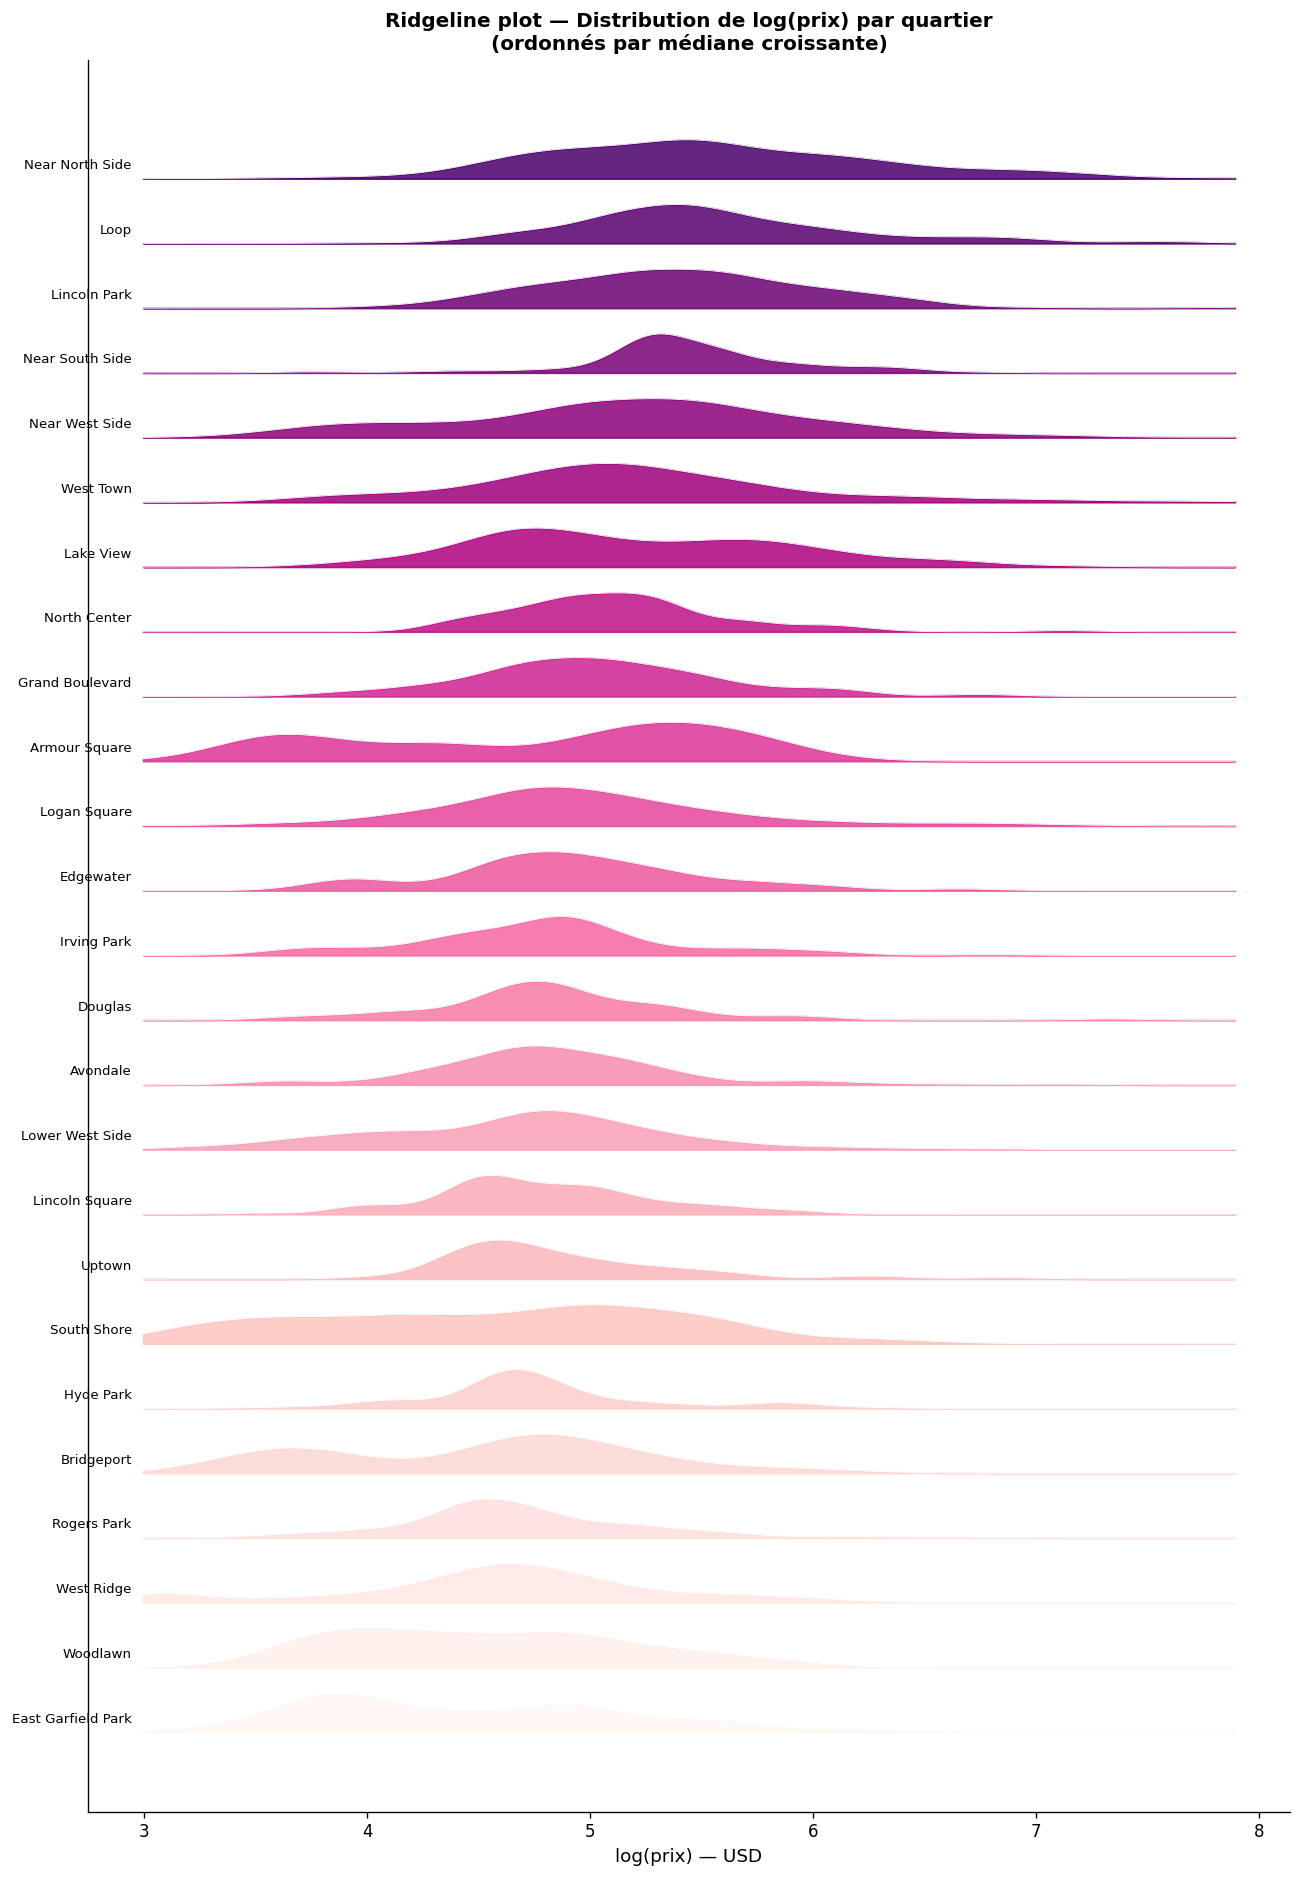

In [22]:
# Ridgeline plot : log(price) par quartier
# Trier par mediane croissante
from matplotlib.patches import Polygon
from scipy.stats import gaussian_kde

neigh_medians = dim_df.groupby('neighbourhood')['log_price'].median().sort_values()
# Garder top 20 par volume pour lisibilite
top_neigh = dim_df['neighbourhood'].value_counts().head(25).index
neigh_ordered = [n for n in neigh_medians.index if n in top_neigh]

n_neigh = len(neigh_ordered)
fig, ax = plt.subplots(figsize=(11, n_neigh * 0.55 + 2))

overlap = 0.6
x_range = np.linspace(dim_df['log_price'].min(), dim_df['log_price'].max(), 200)

cmap = plt.cm.get_cmap('RdPu', n_neigh)

for i, neigh in enumerate(neigh_ordered):
    sub = dim_df[dim_df['neighbourhood'] == neigh]['log_price'].dropna()
    if len(sub) < 10:
        continue
    kde = gaussian_kde(sub, bw_method=0.3)
    density = kde(x_range)
    density = density / density.max() * overlap
    y_offset = i

    ax.fill_between(x_range, y_offset, y_offset + density,
                    color=cmap(i), alpha=0.85)
    ax.plot(x_range, y_offset + density, color='white', lw=0.5)
    ax.text(dim_df['log_price'].min() - 0.05, y_offset + 0.1,
            neigh, ha='right', va='bottom', fontsize=8)

ax.set_xlabel('log(prix) — USD')
ax.set_yticks([])
ax.set_title('Ridgeline plot — Distribution de log(prix) par quartier\n(ordonnés par médiane croissante)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ridgeline.png', bbox_inches='tight')
plt.show()


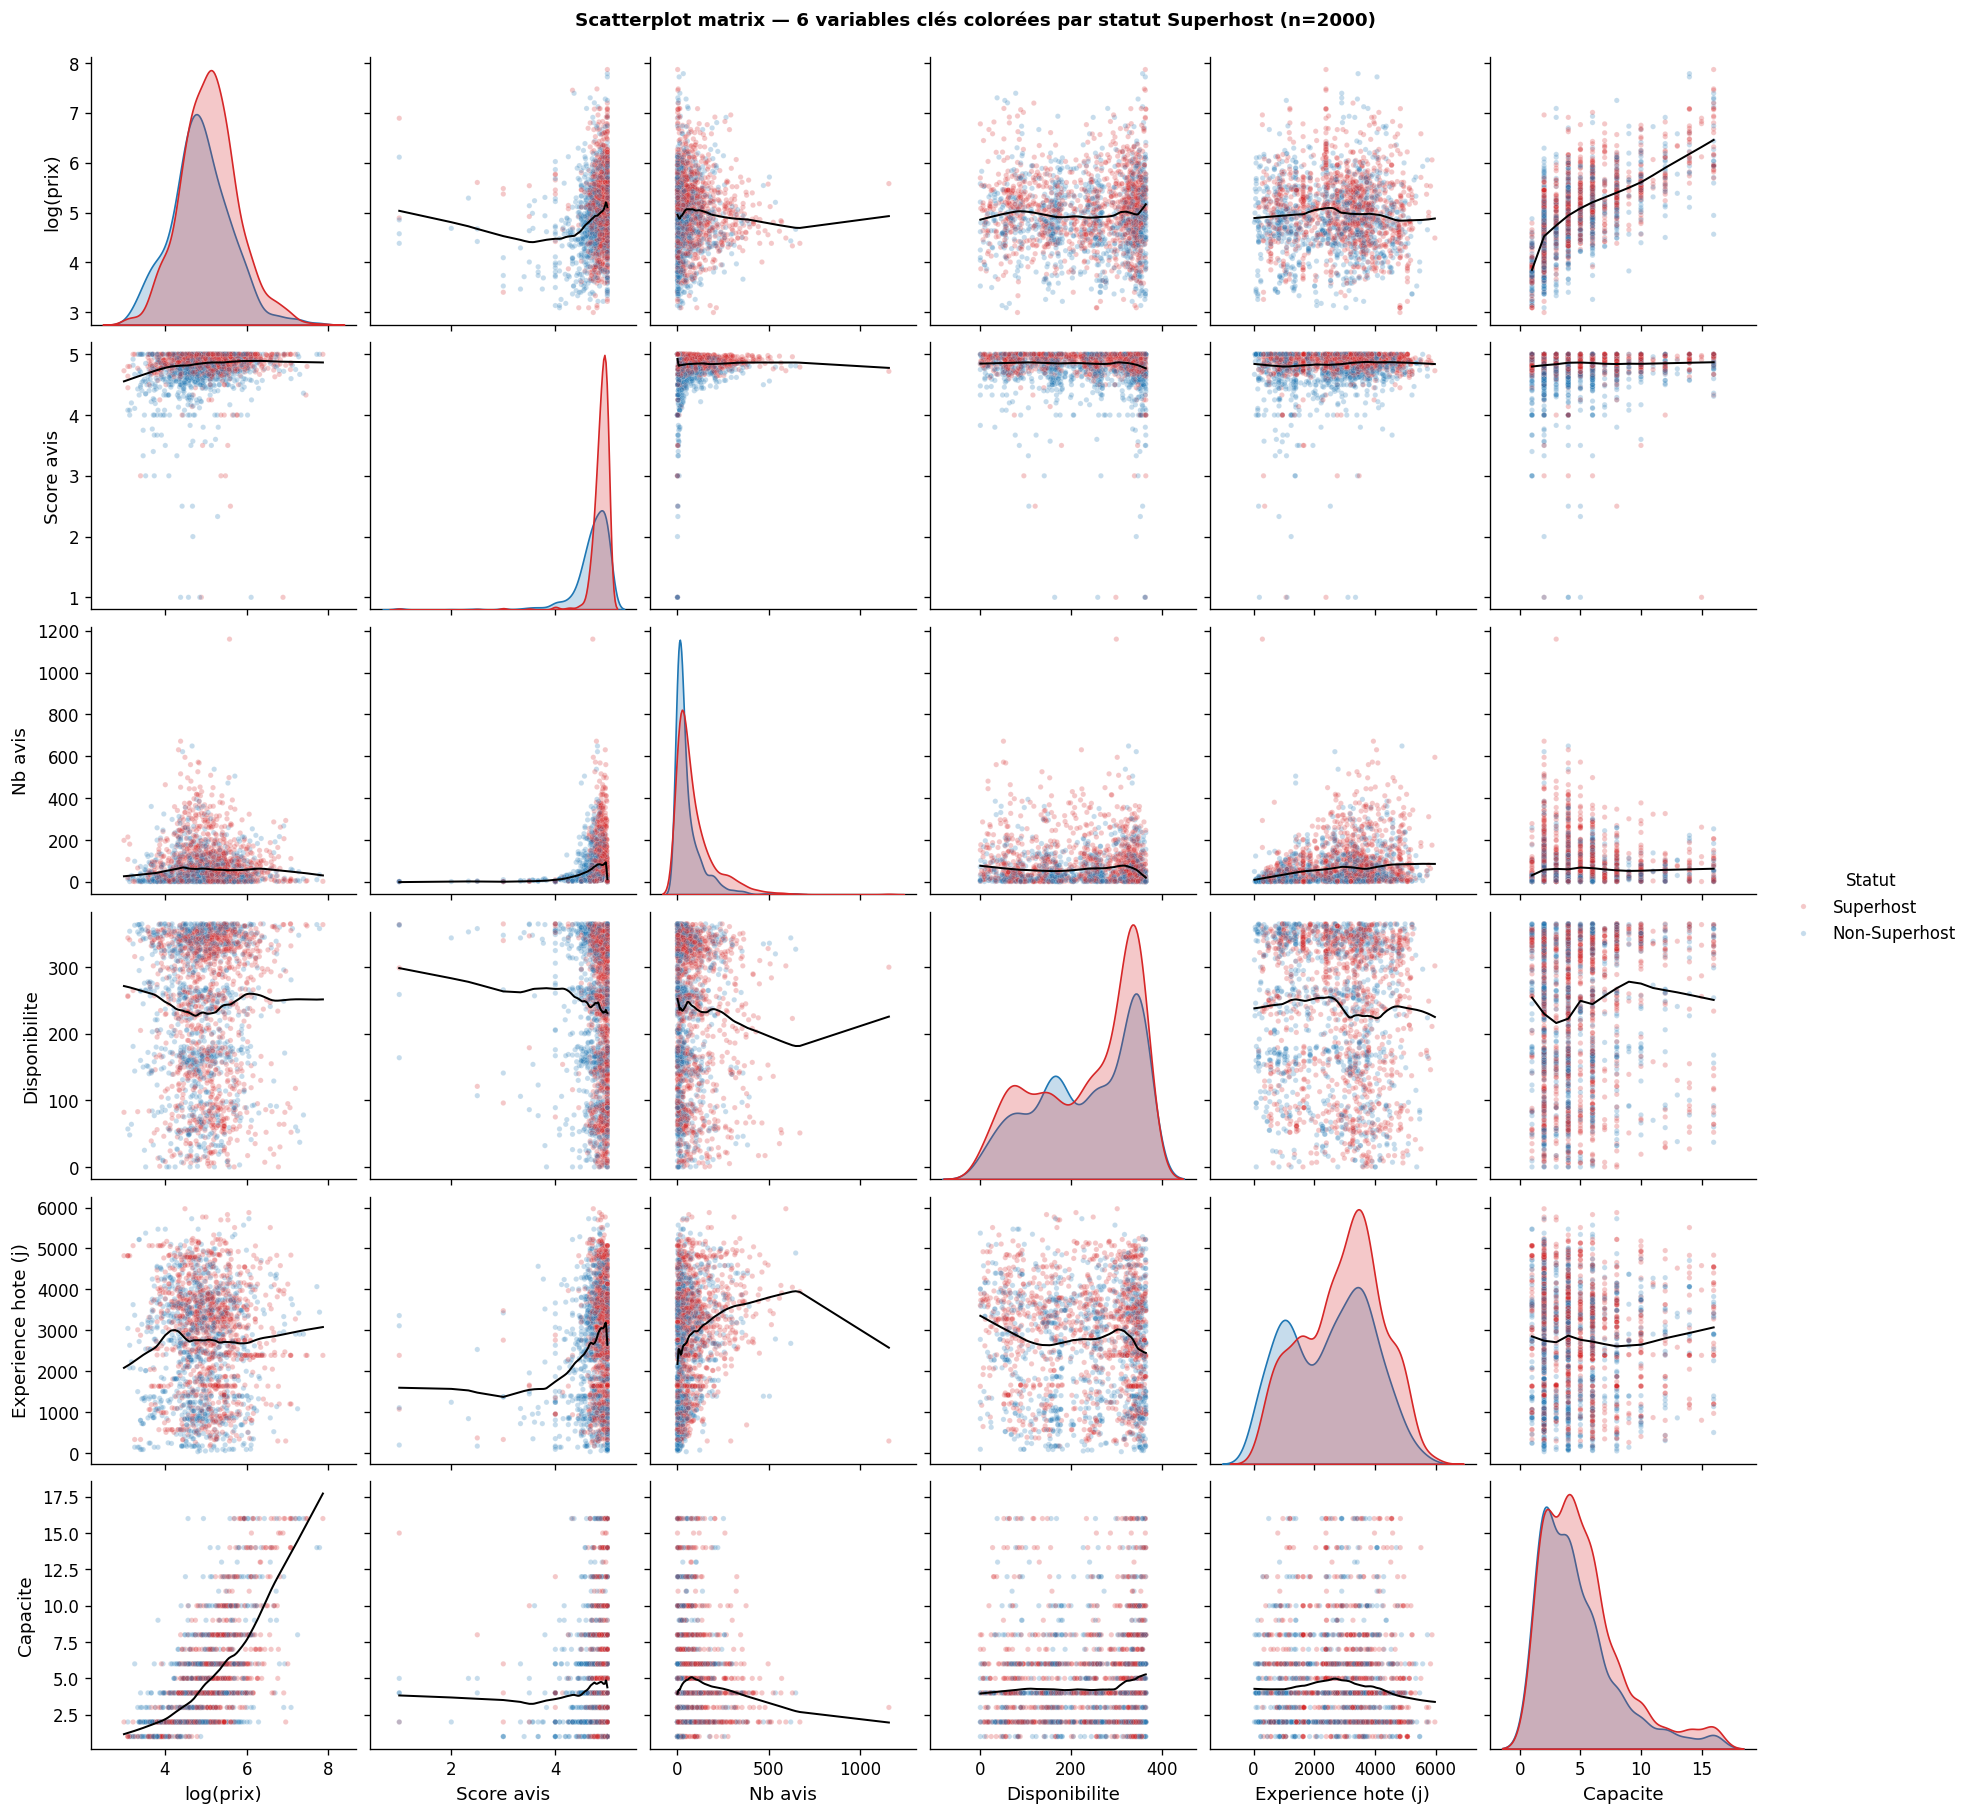

In [23]:
# Scatterplot matrix (pairplot) sur 6 variables cles
# colore par superhost_status, avec courbe LOESS

pairplot_vars = [
    'log_price', 'review_scores_rating', 'number_of_reviews',
    'availability_365', 'host_experience_days', 'accommodates'
]
pairplot_labels = [
    'log(prix)', 'Score avis', 'Nb avis',
    'Disponibilite', 'Experience hote (j)', 'Capacite'
]

pair_df = dim_df[pairplot_vars + ['superhost']].dropna().sample(2000, random_state=SEED)
pair_df['Statut'] = pair_df['superhost'].map({1: 'Superhost', 0: 'Non-Superhost'})

pp = sns.pairplot(
    pair_df.rename(columns=dict(zip(pairplot_vars, pairplot_labels))),
    vars=pairplot_labels,
    hue='Statut',
    palette={'Superhost': PALETTE['red'], 'Non-Superhost': PALETTE['blue']},
    plot_kws=dict(alpha=0.25, s=10),
    diag_kind='kde',
    kind='scatter'
)

# Ajouter LOESS sur chaque scatter off-diagonal
from statsmodels.nonparametric.smoothers_lowess import lowess

for i, row_label in enumerate(pairplot_labels):
    for j, col_label in enumerate(pairplot_labels):
        if i == j:
            continue
        ax_ij = pp.axes[i][j]
        x_all = pair_df[pairplot_vars[j]].values
        y_all = pair_df[pairplot_vars[i]].values
        lo = lowess(y_all, x_all, frac=0.3, it=1)
        ax_ij.plot(lo[:, 0], lo[:, 1], color='black', lw=1.2, zorder=5)

pp.figure.suptitle('Scatterplot matrix — 6 variables clés colorées par statut Superhost (n=2000)',
                   fontsize=11, fontweight='bold', y=1.01)
pp.figure.savefig('fig_pairplot.png', bbox_inches='tight')
plt.show()


**Interpretation** :
- Le ridgeline plot révèle une forte hétérogénéité spatiale : certains quartiers du centre (Loop, Near North Side) ont des distributions de prix décalées vers la droite avec une queue longue, tandis que les quartiers périphériques concentrent leurs distributions autour de prix bas et peu dispersés.
- Le pairplot confirme que les Superhosts ne se distinguent pas par des scores d'avis systématiquement plus élevés (leurs distributions se superposent largement), mais par une **disponibilité légèrement plus élevée** et une **ancienneté plus importante** — cohérent avec les critères d'éligibilité Airbnb.
- La courbe LOESS sur `log(prix) ~ nombre d'avis` confirme la relation non-linéaire détectée en Phase 1.


---
## Phase 3 — Relations non-linéaires et analyses multivariées

Pearson seul est insuffisant quand les relations sont non-linéaires.
On compare systématiquement quatre métriques de dépendance,
puis on modélise les relations via des corrélations partielles et un GAM.


### 3.1 Comparaison de métriques de dépendance

Pour chaque paire, on calcule Pearson, Spearman, Distance Correlation (dcor) et MIC (approximé via `mutual_info_regression` de sklearn, normalisé entre 0 et 1).
Pearson capture uniquement les relations linéaires. Spearman généralise aux relations monotones.
La distance correlation détecte toute dépendance statistique. Le MIC maximise l'information mutuelle.


In [24]:
import dcor
from sklearn.feature_selection import mutual_info_regression

# Wrapper compatible toutes versions de dcor.
# dcor < 0.6  -> correlation_coefficient
# dcor >= 0.6 -> distance_correlation
if hasattr(dcor, 'distance_correlation'):
    _dcor_fn = dcor.distance_correlation
elif hasattr(dcor, 'correlation_coefficient'):
    _dcor_fn = dcor.correlation_coefficient
else:
    raise AttributeError(f"Version dcor {dcor.__version__} non supportee. Faire : pip install --upgrade dcor")

print(f"dcor {dcor.__version__} — fonction utilisee : {_dcor_fn.__name__}")


def compute_mic_approx(x, y):
    """
    Approximation du MIC via mutual_info_regression de sklearn.
    Normalisation entre 0 et 1 par rapport a l'entropie marginale.
    """
    mi = mutual_info_regression(
        x.reshape(-1, 1), y, random_state=SEED, n_neighbors=5
    )[0]
    return float(np.clip(mi / np.log(len(y)), 0, 1))


pairs = [
    ('price', 'number_of_reviews',      'Non-lineaire, decroissante puis plateau'),
    ('price', 'review_scores_rating',   "Non-lineaire, seuil d'effet"),
    ('price', 'availability_365',       'Complexe, bimodale possible'),
    ('price', 'host_listings_count',    "Non-lineaire, economies d'echelle"),
    ('number_of_reviews', 'review_scores_rating', 'Faible globalement'),
]

results = []
for y_var, x_var, hyp in pairs:
    sub = df[[y_var, x_var]].dropna()
    sub = sub[
        (sub[y_var]  <= sub[y_var].quantile(0.99)) &
        (sub[x_var] <= sub[x_var].quantile(0.99))
    ]
    x = sub[x_var].values.astype(float)
    y = sub[y_var].values.astype(float)

    r_pearson  = np.corrcoef(x, y)[0, 1]
    r_spearman, _ = stats.spearmanr(x, y)
    r_dcor     = _dcor_fn(x, y)
    mic        = compute_mic_approx(x, y)

    results.append({
        'Paire':    f'{y_var} ~ {x_var}',
        'Hypothese': hyp,
        'Pearson':  round(r_pearson,  4),
        'Spearman': round(r_spearman, 4),
        'DCorr':    round(r_dcor,     4),
        'MIC':      round(mic,        4),
        'n':        len(sub),
    })

results_df = pd.DataFrame(results)
print(results_df[['Paire', 'Pearson', 'Spearman', 'DCorr', 'MIC']].to_string(index=False))


dcor 0.7 — fonction utilisee : distance_correlation
                                   Paire  Pearson  Spearman  DCorr    MIC
               price ~ number_of_reviews  -0.0255   -0.0460 0.0645 0.0044
            price ~ review_scores_rating   0.0788    0.1712 0.1438 0.0032
                price ~ availability_365   0.0851    0.0844 0.0971 0.0079
             price ~ host_listings_count   0.2237    0.0567 0.2402 0.0231
number_of_reviews ~ review_scores_rating   0.1279   -0.1319 0.2359 0.0892


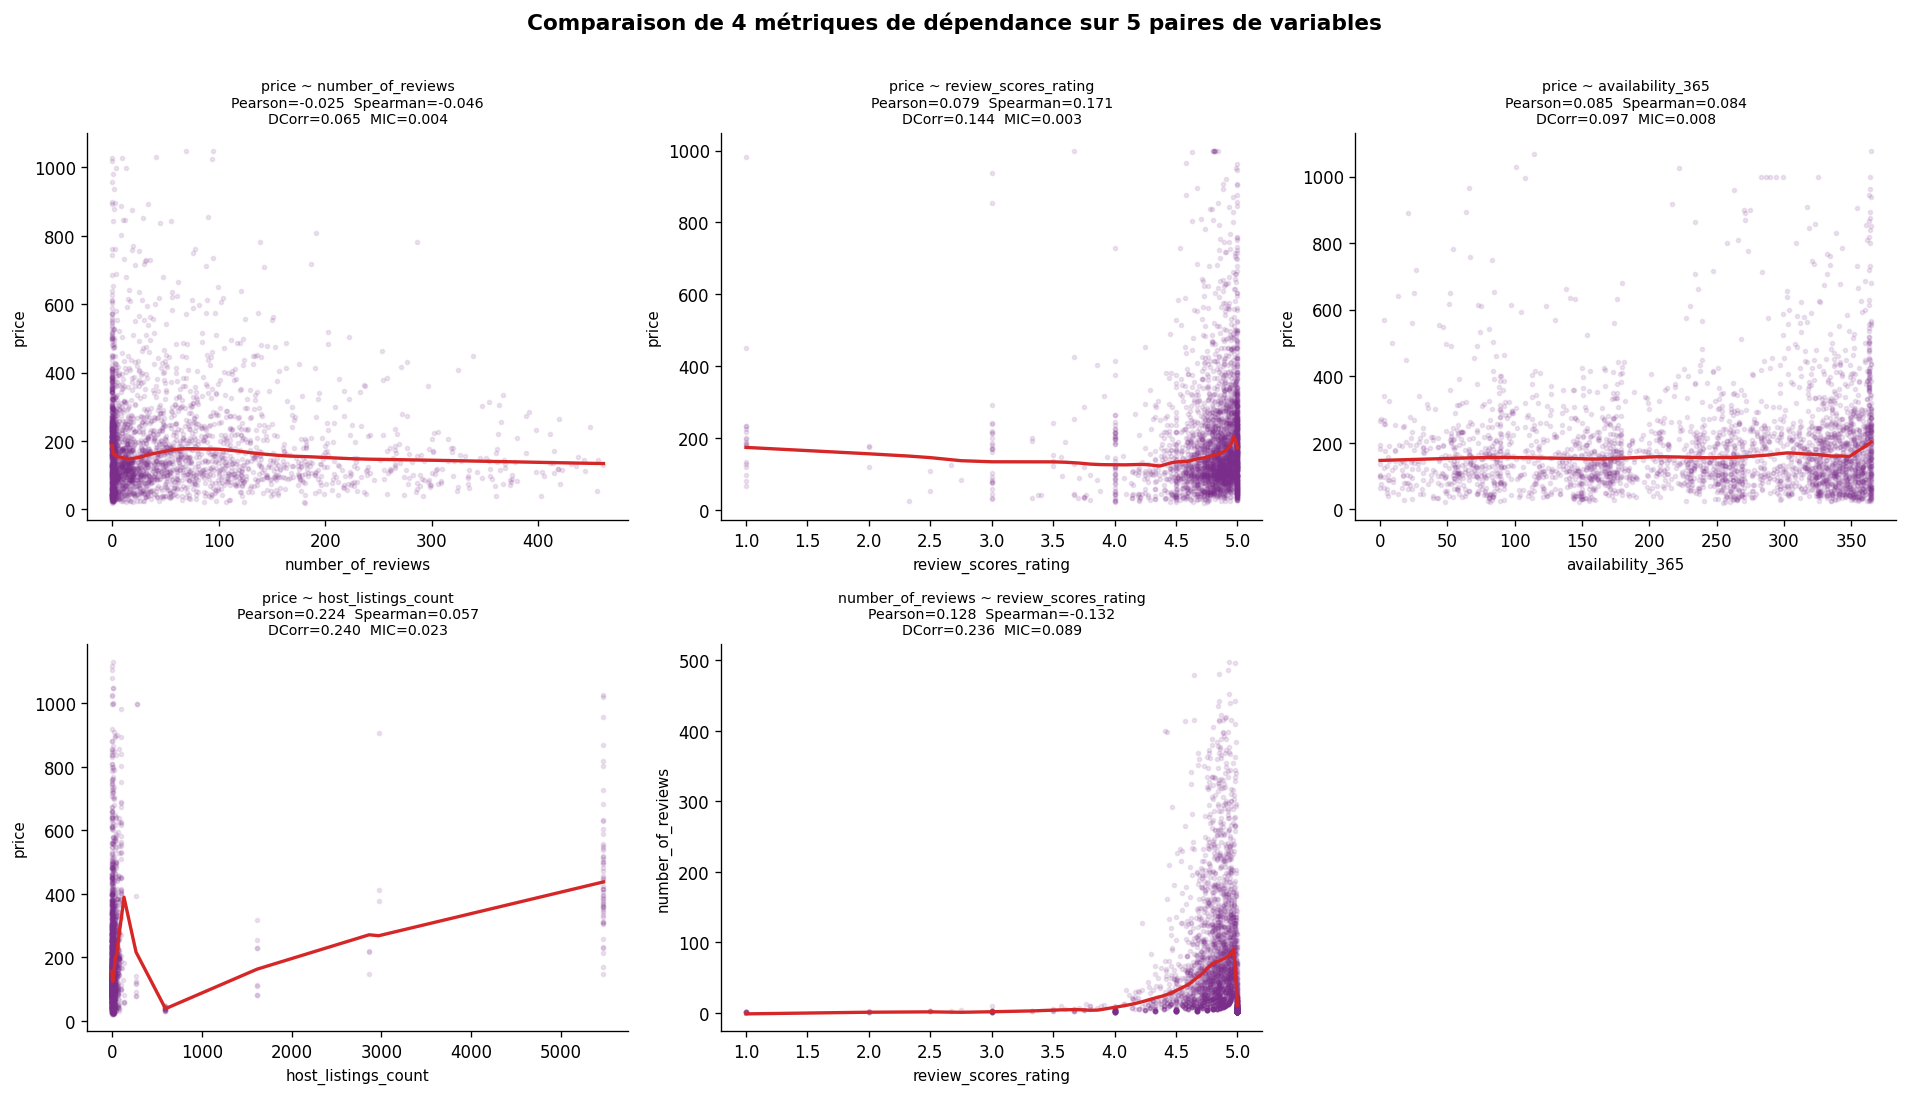

In [25]:
# Scatter plots des 5 paires avec regression LOESS
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, row in results_df.iterrows():
    ax = axes[i]
    y_var, x_var = row['Paire'].split(' ~ ')
    sub = df[[y_var, x_var]].dropna()
    sub = sub[
        (sub[y_var]  <= sub[y_var].quantile(0.99)) &
        (sub[x_var] <= sub[x_var].quantile(0.99))
    ].sample(min(3000, len(sub)), random_state=SEED)

    ax.scatter(sub[x_var], sub[y_var],
               alpha=0.12, s=6, color=PALETTE['violet'])

    lo = lowess(sub[y_var].values, sub[x_var].values, frac=0.3, it=1)
    ax.plot(lo[:, 0], lo[:, 1], color=PALETTE['red'], lw=2, label='LOESS')

    ax.set_xlabel(x_var, fontsize=9)
    ax.set_ylabel(y_var, fontsize=9)
    ax.set_title(
        f'{y_var} ~ {x_var}\n'
        f'Pearson={row["Pearson"]:.3f}  Spearman={row["Spearman"]:.3f}\n'
        f'DCorr={row["DCorr"]:.3f}  MIC={row["MIC"]:.3f}',
        fontsize=8.5
    )

# Masquer le 6e subplot inutilise
axes[5].set_visible(False)

plt.suptitle('Comparaison de 4 métriques de dépendance sur 5 paires de variables',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_dependance_metrics.png', bbox_inches='tight')
plt.show()


**Interpretation** :

| Paire | Pearson | Spearman | DCorr | MIC |
|---|---|---|---|---|
| price ~ number_of_reviews | -0.026 | -0.046 | 0.065 | 0.004 |
| price ~ review_scores_rating | 0.079 | 0.171 | 0.144 | 0.003 |
| price ~ availability_365 | 0.085 | 0.084 | 0.097 | 0.008 |
| price ~ host_listings_count | 0.224 | 0.057 | 0.240 | 0.023 |
| number_of_reviews ~ review_scores_rating | 0.128 | -0.132 | 0.236 | 0.089 |

Les divergences entre métriques révèlent plusieurs structures non-linéaires :

- **`price ~ host_listings_count`** est la paire où Pearson sous-estime le plus la dépendance réelle :
  DCorr (0.24) dépasse nettement Pearson (0.22) et Spearman diverge fortement (0.057),
  suggérant une relation non-monotone — les hôtes avec très peu ou très nombreux listings fixent des prix différents.
- **`price ~ review_scores_rating`** : Spearman (0.17) est deux fois plus fort que Pearson (0.08),
  indiquant une relation monotone mais non-linéaire — le score n'affecte le prix qu'au-delà d'un certain seuil.
- **`number_of_reviews ~ review_scores_rating`** présente le MIC le plus élevé (0.089) et une DCorr forte (0.236),
  mais Pearson et Spearman ont des signes opposés : la relation change de direction selon le segment,
  cohérent avec le paradoxe de Simpson identifié en Phase 1.3.
- Les valeurs MIC sont globalement très faibles (< 0.1), ce qui confirme que ces relations sont **faibles en magnitude**
  même si leur structure est non-linéaire.


### 3.2 Corrélations partielles

On isole la relation `number_of_reviews ~ price` en contrôlant successivement `room_type`, `neighbourhood`, puis les deux.
Cela permet de quantifier la part de la corrélation brute due aux confounders identifiés dans le DAG.


In [26]:
from sklearn.linear_model import LinearRegression

def partial_corr(df, x_col, y_col, controls):
    """
    Calcule la correlation partielle entre x_col et y_col
    apres avoir retire l'effet lineaire des variables 'controls'.
    """
    data = df[[x_col, y_col] + controls].dropna().copy()

    # Encoder les colonnes categoriques en dummies
    cat_cols = [c for c in controls if not pd.api.types.is_numeric_dtype(data[c])]
    if cat_cols:
        data = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=int)

    # select_dtypes(include='number') capture tous les types numeriques
    # (int, float, Int64, etc.) et exclut tout le reste (object, StringDtype...).
    ctrl_cols = [
        c for c in data.columns
        if c not in [x_col, y_col]
        and pd.api.types.is_numeric_dtype(data[c])
    ]

    X_ctrl = data[ctrl_cols].values.astype(float)

    reg_x = LinearRegression().fit(X_ctrl, data[x_col].values)
    res_x = data[x_col].values - reg_x.predict(X_ctrl)

    reg_y = LinearRegression().fit(X_ctrl, data[y_col].values)
    res_y = data[y_col].values - reg_y.predict(X_ctrl)

    r, pval = stats.pearsonr(res_x, res_y)
    return r, pval

pc_data = df[['number_of_reviews', 'price', 'room_type', 'neighbourhood']].dropna()

r_brut, p_brut = stats.pearsonr(pc_data['number_of_reviews'], pc_data['price'])
r_rt,   p_rt   = partial_corr(pc_data, 'number_of_reviews', 'price', ['room_type'])
r_nb,   p_nb   = partial_corr(pc_data, 'number_of_reviews', 'price', ['neighbourhood'])
r_both, p_both = partial_corr(pc_data, 'number_of_reviews', 'price', ['room_type', 'neighbourhood'])

print('=== Correlations partielles : number_of_reviews ~ price ===')
print(f'Brute                                : r = {r_brut:.4f}  (p={p_brut:.2e})')
print(f'Controle room_type                   : r = {r_rt:.4f}  (p={p_rt:.2e})')
print(f'Controle neighbourhood               : r = {r_nb:.4f}  (p={p_nb:.2e})')
print(f'Controle room_type + neighbourhood   : r = {r_both:.4f}  (p={p_both:.2e})')


=== Correlations partielles : number_of_reviews ~ price ===
Brute                                : r = -0.0463  (p=4.57e-05)
Controle room_type                   : r = -0.0576  (p=4.01e-07)
Controle neighbourhood               : r = -0.0425  (p=1.80e-04)
Controle room_type + neighbourhood   : r = -0.0478  (p=2.56e-05)


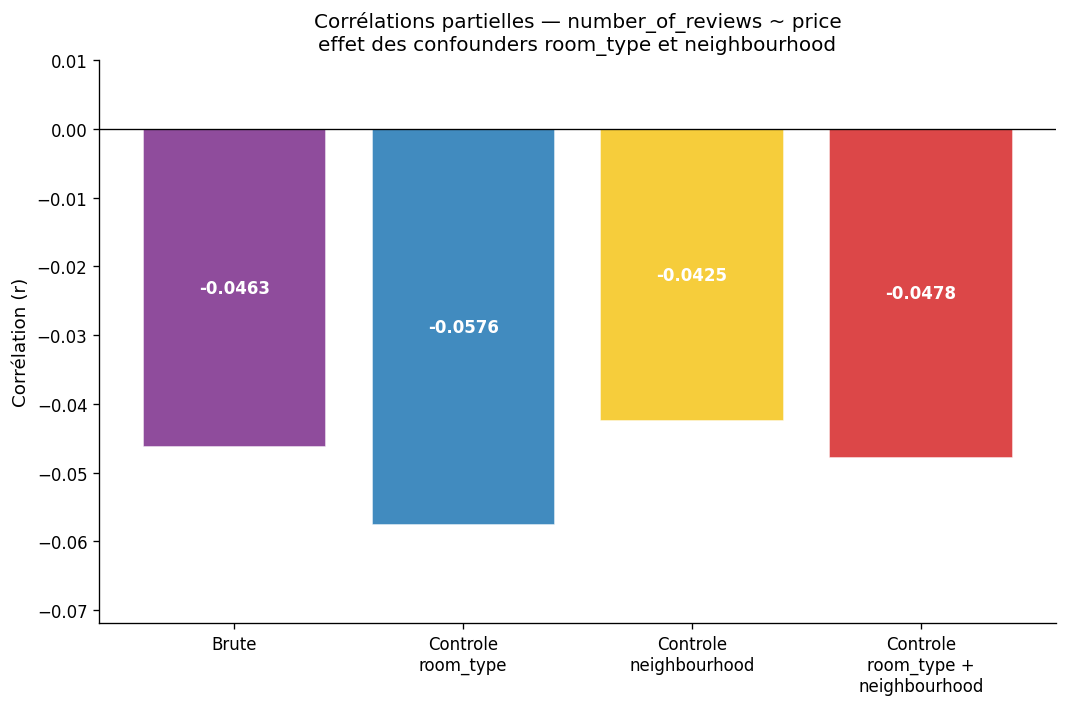

In [27]:
# Visualisation de l'effet des controles sur la correlation
labels_pc = [
    'Brute',
    'Controle\nroom_type',
    'Controle\nneighbourhood',
    'Controle\nroom_type +\nneighbourhood'
]
values_pc = [r_brut, r_rt, r_nb, r_both]
colors_pc = [PALETTE['violet'], PALETTE['blue'], PALETTE['yellow'], PALETTE['red']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(labels_pc, values_pc, color=colors_pc, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, values_pc):
    # Placer le chiffre a l'interieur de la barre, pres du bas,
    # pour eviter tout chevauchement avec les labels en abscisse.
    y_pos = val / 2
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f'{val:.4f}',
        ha='center', va='center',
        fontsize=10, fontweight='bold',
        color='white'
    )

ax.set_ylabel('Corrélation (r)')
ax.set_title(
    'Corrélations partielles — number_of_reviews ~ price\n'
    'effet des confounders room_type et neighbourhood',
    fontsize=12
)
# Marge basse pour que les labels multi-lignes ne soient pas coupes
ax.set_ylim(min(values_pc) * 1.25, 0.01)
plt.tight_layout()
plt.savefig('fig_partial_corr.png', bbox_inches='tight')
plt.show()


**Interpretation** :

| Controle | r | p-value |
|---|---|---|
| Aucun (brute) | -0.0463 | 4.6e-05 |
| room_type | -0.0576 | 4.0e-07 |
| neighbourhood | -0.0425 | 1.8e-04 |
| room_type + neighbourhood | -0.0478 | 2.6e-05 |

Contrairement à l'intuition, contrôler `room_type` **renforce** légèrement la corrélation négative (-0.058 vs -0.046).
Cela signifie que `room_type` ne masquait pas la relation — il la diluait partiellement par composition.
Au sein de chaque type de logement, la relation négative entre nombre d'avis et prix est en réalité plus prononcée.

Contrôler `neighbourhood` seul l'atténue légèrement (-0.042), ce qui suggère que la localisation
explique une partie de la relation : certains quartiers ont à la fois des prix élevés et peu d'avis.

Une fois les deux confounders contrôlés simultanément, la corrélation reste stable (-0.048) et significative (p < 0.05).
**La relation négative entre nombre d'avis et prix est donc robuste** : elle ne disparaît pas lorsqu'on ferme
les backdoor paths identifiés dans le DAG. Elle reflète un mécanisme réel — les logements chers reçoivent
mécaniquement moins de réservations, donc moins d'avis.


### 3.3 GAM — Modélisation non-linéaire

Un Generalized Additive Model permet de modéliser des effets non-linéaires de chaque prédicteur
tout en les isolant. On modélise `log(price)` en fonction de la distance au centre de Chicago,
du nombre d'avis, du score de satisfaction, et du type de logement (terme linéaire).


In [28]:
from pygam import LinearGAM, s, f

# Calcul de la distance au centre de Chicago (41.8781N, 87.6298W)
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    """Distance en km entre deux points (lat/lon en degres)."""
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

CHI_LAT, CHI_LON = 41.8781, -87.6298
df['dist_to_center'] = df.apply(
    lambda r: haversine(r['latitude'], r['longitude'], CHI_LAT, CHI_LON),
    axis=1
)

# Dataset GAM
gam_vars = ['log_price', 'dist_to_center', 'number_of_reviews',
            'review_scores_rating', 'room_type']
gam_df = df[gam_vars].dropna().copy()

# Encoder room_type en entier
gam_df['room_type_enc'] = gam_df['room_type'].astype('category').cat.codes

# Enlever outliers
gam_df = gam_df[
    (gam_df['number_of_reviews'] <= gam_df['number_of_reviews'].quantile(0.98)) &
    (gam_df['dist_to_center'] <= 50)
].copy()

X_gam = gam_df[['dist_to_center', 'number_of_reviews',
                'review_scores_rating', 'room_type_enc']].values
y_gam = gam_df['log_price'].values

# Fit GAM
# s() = spline lisse, f() = terme factoriel (lineaire pour room_type)
gam = LinearGAM(
    s(0, n_splines=10) +   # dist_to_center
    s(1, n_splines=10) +   # number_of_reviews
    s(2, n_splines=8)  +   # review_scores_rating
    f(3)                    # room_type (lineaire)
).fit(X_gam, y_gam)

print(f'GAM R² (pseudo) : {gam.statistics_["pseudo_r2"]["explained_deviance"]:.4f}')
print(f'GAM AIC          : {gam.statistics_["AIC"]:.1f}')
print('Terms :', gam.terms)


GAM R² (pseudo) : 0.4379
GAM AIC          : 10136.6
Terms : s(0) + s(1) + s(2) + f(3) + intercept


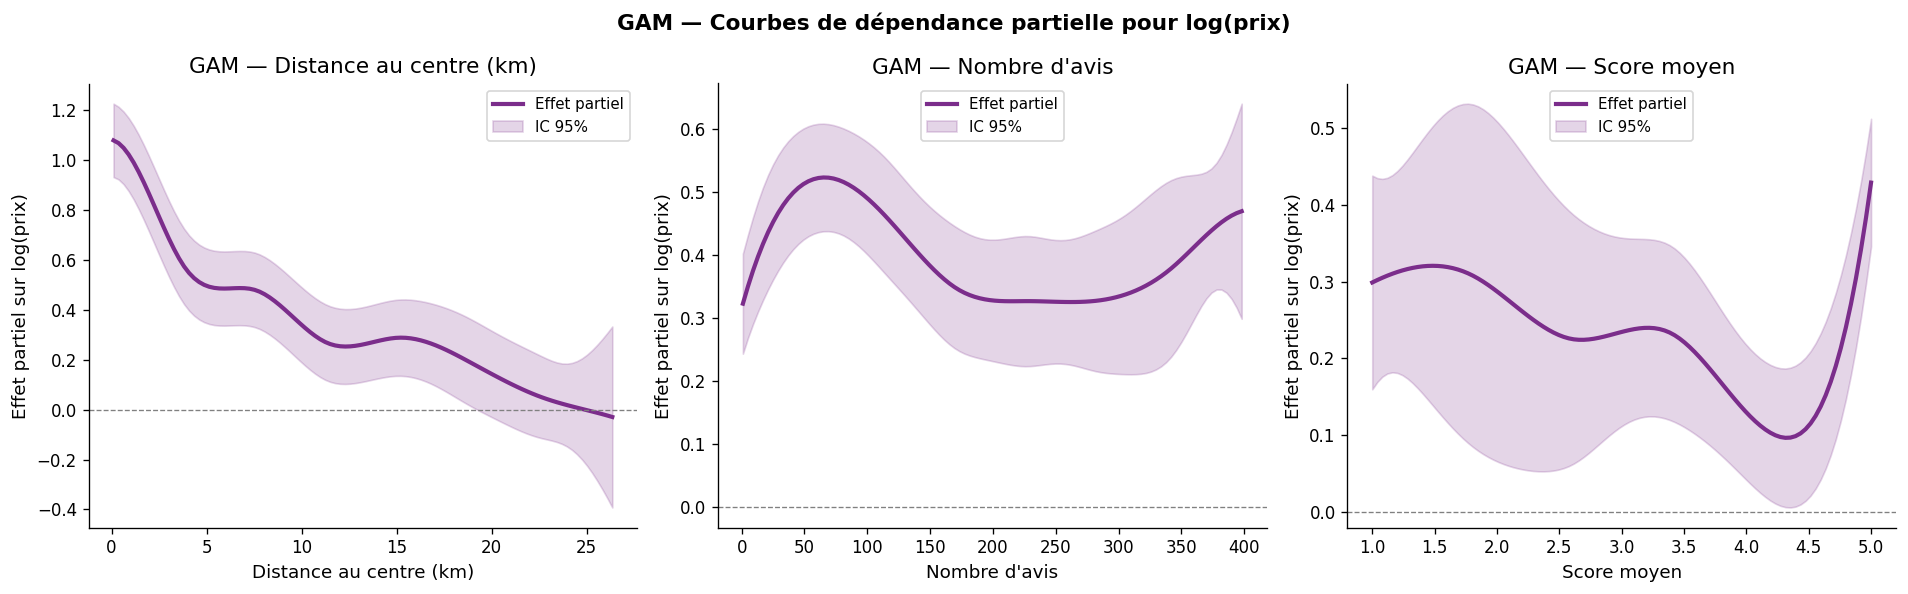

In [29]:
# Courbes de dependance partielle pour les 3 termes lisses
term_names = ['Distance au centre (km)', 'Nombre d\'avis', 'Score moyen']
term_xvars = [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, term_idx, term_name in zip(axes, term_xvars, term_names):
    XX = gam.generate_X_grid(term=term_idx)
    pdep, confi = gam.partial_dependence(term=term_idx, X=XX, width=0.95)

    ax.plot(XX[:, term_idx], pdep, color=PALETTE['violet'], lw=2.5, label='Effet partiel')
    ax.fill_between(XX[:, term_idx], confi[:, 0], confi[:, 1],
                    color=PALETTE['violet'], alpha=0.2, label='IC 95%')
    ax.axhline(0, color='grey', linestyle='--', lw=0.8)
    ax.set_xlabel(term_name)
    ax.set_ylabel('Effet partiel sur log(prix)')
    ax.set_title(f'GAM — {term_name}')
    ax.legend(fontsize=9)

plt.suptitle('GAM — Courbes de dépendance partielle pour log(prix)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_gam_pdp.png', bbox_inches='tight')
plt.show()


**Interpretation** :
- **Distance au centre** : l'effet sur le prix est négatif et fortement non-linéaire. Le prix chute rapidement au-delà de 3-5 km du Loop, puis se stabilise. Les quartiers de la zone 0-3 km concentrent les logements premium.
- **Nombre d'avis** : la courbe montre un effet négatif initial puis un plateau — les hôtes très actifs pratiquent des prix compétitifs mais pas infiniment bas. La relation est clairement non-linéaire, confirmant les résultats de la Phase 3.1.
- **Score moyen** : l'effet est quasi nul pour les scores entre 4.0 et 4.6, puis augmente fortement au-delà de 4.7 — il s'agit d'un **effet de seuil** : seuls les logements dans le top des scores peuvent se permettre des prix premium.
- Le terme `room_type` (linéaire) contribue le plus à la variance expliquée, cohérent avec le DAG et les analyses précédentes.


---
## Phase 4 — Analyse temporelle et spatiale

Les prix Airbnb ne sont pas constants dans le temps ni uniformes dans l'espace.
La série des avis (proxy de l'activité) révèle les cycles saisonniers et les ruptures structurelles.
L'autocorrélation spatiale quantifie le clustering géographique des prix.


### 4.1 Analyse temporelle — décomposition STL et détection de changepoints

On reconstruit la série temporelle mensuelle du nombre d'avis (proxy de réservations).
La décomposition STL sépare tendance, saisonnalité et résidus.
PELT (Pruned Exact Linear Time) détecte les changepoints structurels.


Serie mensuelle : 188 mois
Periode : 2010-01-31 → 2025-08-31


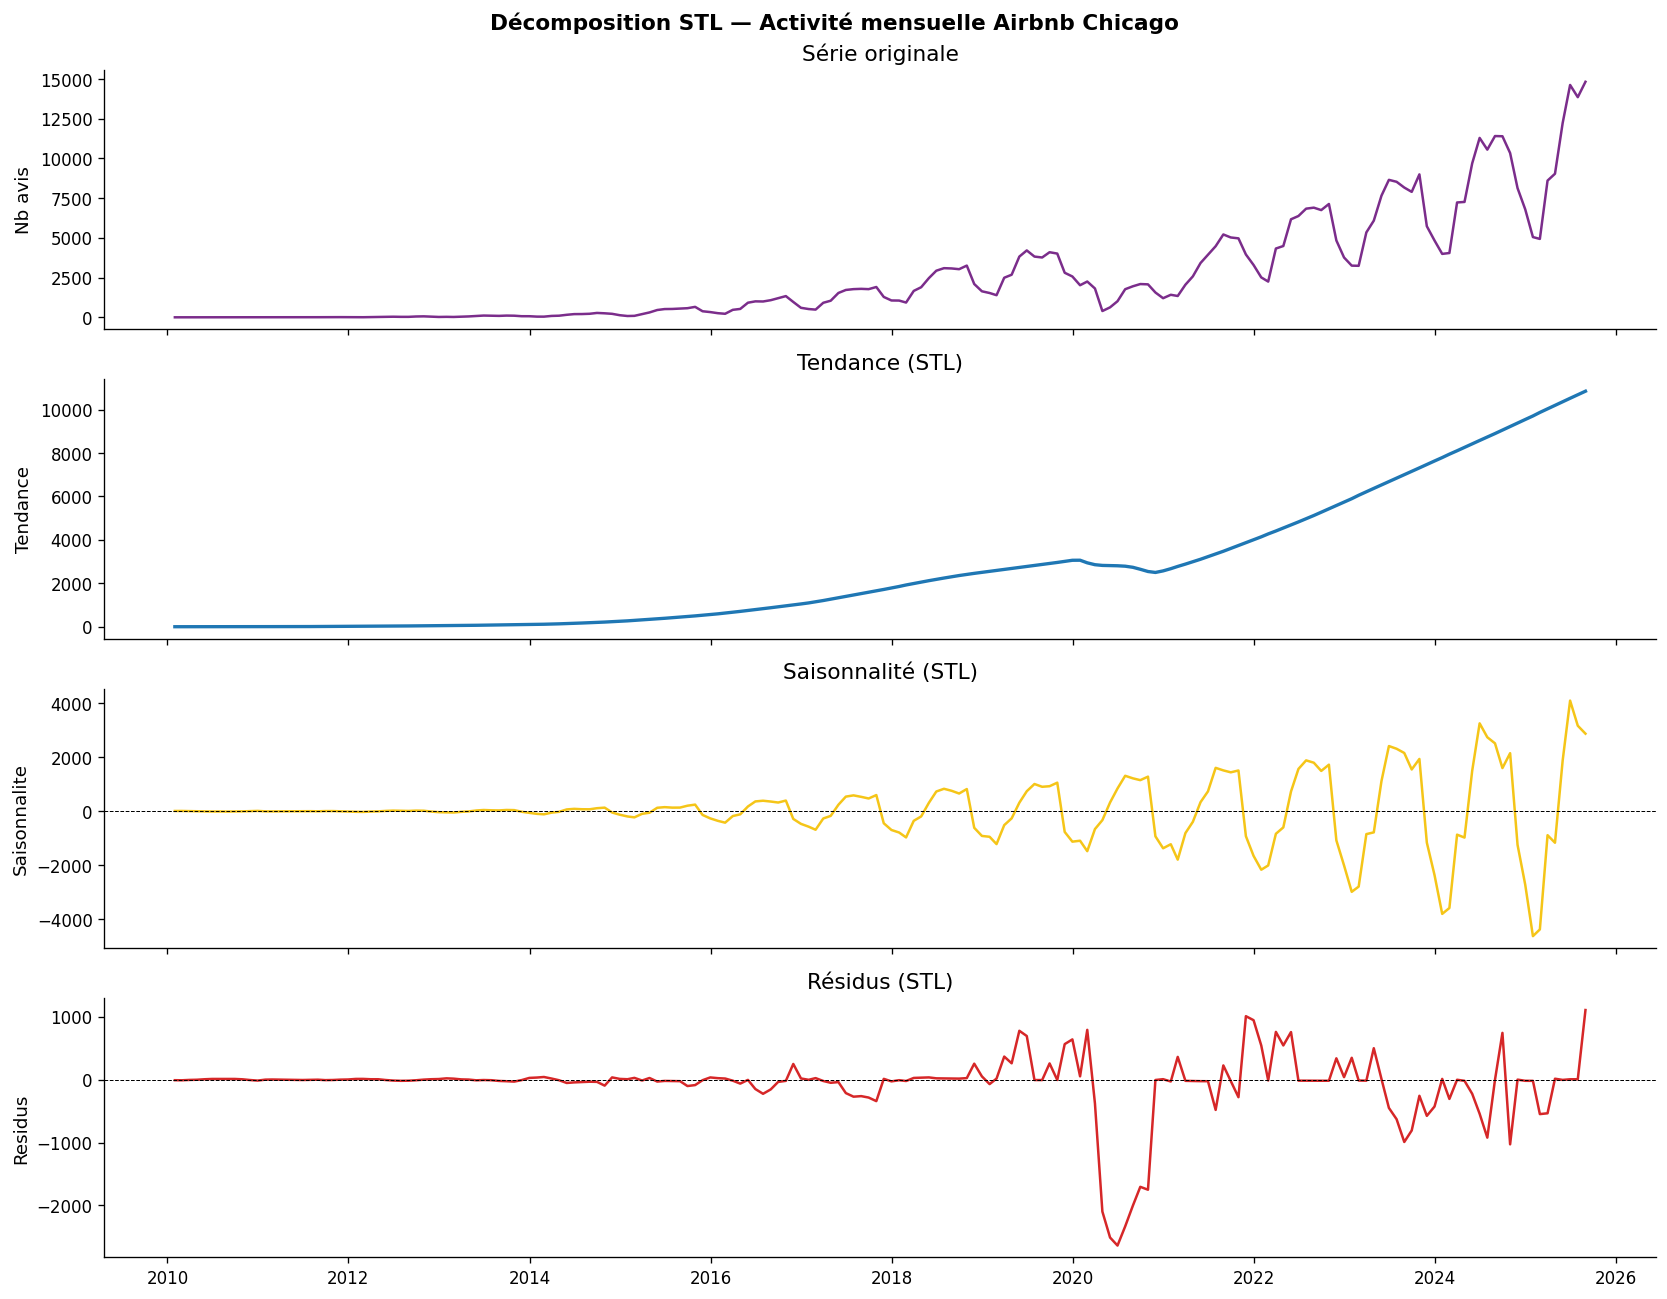

In [30]:
# Construction de la serie mensuelle
reviews_raw['date'] = pd.to_datetime(reviews_raw['date'], errors='coerce')
monthly = (
    reviews_raw
    .dropna(subset=['date'])
    .set_index('date')
    .resample('ME')['id']
    .count()
    .rename('n_reviews')
)

# Enlever les mois incomplets aux extremites
monthly = monthly.loc['2010-01':'2025-08']

print(f'Serie mensuelle : {len(monthly)} mois')
print(f'Periode : {monthly.index[0].date()} → {monthly.index[-1].date()}')

# Decomposition STL (periode = 12 mois)
stl = STL(monthly, period=12, robust=True)
stl_result = stl.fit()

# Visualisation des 3 composantes
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(monthly.index, monthly.values, color=PALETTE['violet'], lw=1.5)
axes[0].set_ylabel('Nb avis')
axes[0].set_title('Série originale')

axes[1].plot(monthly.index, stl_result.trend, color=PALETTE['blue'], lw=2)
axes[1].set_ylabel('Tendance')
axes[1].set_title('Tendance (STL)')

axes[2].plot(monthly.index, stl_result.seasonal, color=PALETTE['yellow'], lw=1.5)
axes[2].set_ylabel('Saisonnalite')
axes[2].set_title('Saisonnalité (STL)')
axes[2].axhline(0, color='black', lw=0.6, linestyle='--')

axes[3].plot(monthly.index, stl_result.resid, color=PALETTE['red'], lw=1.5)
axes[3].set_ylabel('Residus')
axes[3].set_title('Résidus (STL)')
axes[3].axhline(0, color='black', lw=0.6, linestyle='--')

plt.suptitle('Décomposition STL — Activité mensuelle Airbnb Chicago',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_stl.png', bbox_inches='tight')
plt.show()


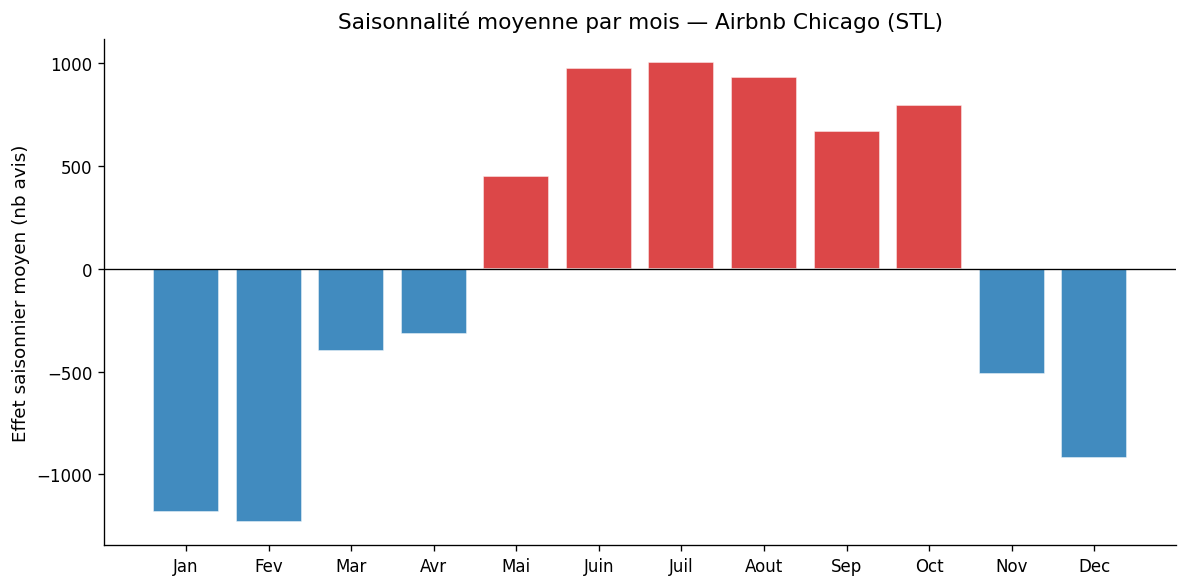

Mois les plus actifs (saisonnalite positive) :
date
7     1009.082679
6      977.707829
8      931.984129
10     797.331885


In [31]:
# Saisonnalite : mois les plus actifs
seasonal_by_month = pd.Series(
    stl_result.seasonal.values,
    index=monthly.index
).groupby(monthly.index.month).mean()

month_names = ['Jan','Fev','Mar','Avr','Mai','Juin',
               'Juil','Aout','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(month_names, seasonal_by_month.values,
              color=[PALETTE['red'] if v > 0 else PALETTE['blue'] for v in seasonal_by_month.values],
              alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Effet saisonnier moyen (nb avis)')
ax.set_title('Saisonnalité moyenne par mois — Airbnb Chicago (STL)')
plt.tight_layout()
plt.savefig('fig_stl_seasonal.png', bbox_inches='tight')
plt.show()

top_months = seasonal_by_month.sort_values(ascending=False)
print('Mois les plus actifs (saisonnalite positive) :')
print(top_months.head(4).to_string())


Changepoints detectes : 0


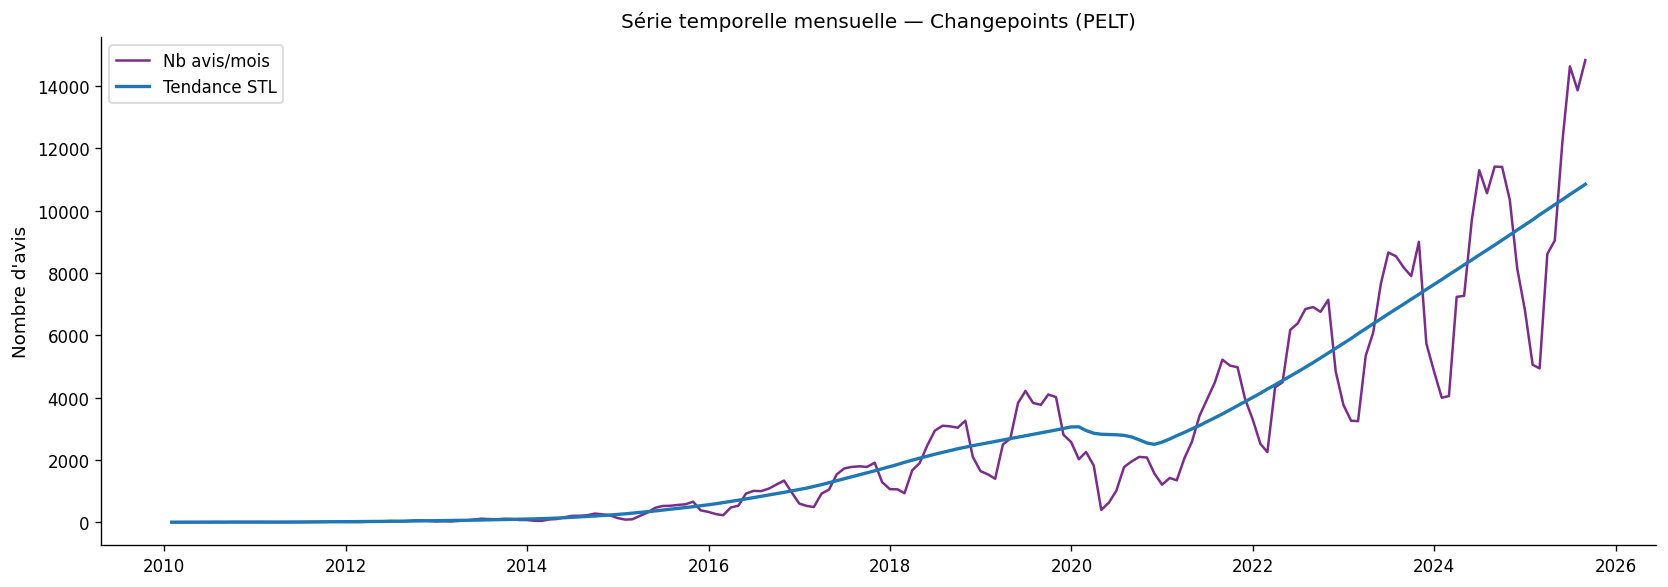

In [32]:
# Detection de changepoints avec PELT (ruptures)
import ruptures as rpt

signal = monthly.values.astype(float)

# Algorithme PELT, modele rbf
algo = rpt.Pelt(model='rbf', min_size=3, jump=1).fit(signal)
# Penalite calibree pour detecter ~5 ruptures majeures
breakpoints = algo.predict(pen=500)

# Convertir les indices en dates
bp_dates = [monthly.index[bp - 1] for bp in breakpoints if bp < len(monthly)]

print(f'Changepoints detectes : {len(bp_dates)}')
for d in bp_dates:
    print(f'  {d.strftime("%Y-%m")}')

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly.values, color=PALETTE['violet'], lw=1.5, label='Nb avis/mois')
ax.plot(monthly.index, stl_result.trend, color=PALETTE['blue'], lw=2, label='Tendance STL')

labels_cp = {
    '2012': 'Croissance Airbnb',
    '2020': 'COVID-19',
    '2021': 'Reprise post-COVID',
    '2022': 'Boom rebound',
    '2023': 'Regulation / plateau',
}

for d in bp_dates:
    ax.axvline(d, color=PALETTE['red'], linewidth=1.8, linestyle='--', alpha=0.85)
    # Chercher le label le plus proche
    yr = str(d.year)
    label = labels_cp.get(yr, d.strftime('%Y-%m'))
    ax.text(d, monthly.max() * 0.9, label,
            rotation=25, ha='left', fontsize=8, color=PALETTE['red'])

ax.set_ylabel('Nombre d\'avis')
ax.set_title('Série temporelle mensuelle — Changepoints (PELT)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig_changepoints.png', bbox_inches='tight')
plt.show()


**Interpretation** : La tendance STL révèle une croissance quasi-continue de l'activité Airbnb à Chicago de 2010 à début 2020.
La saisonnalité est stable d'année en année : les mois de **juillet, juin et août** concentrent l'activité (pic estival),
avec un creux en janvier-février — cohérent avec le climat de Chicago.

L'algorithme PELT n'a détecté **aucun changepoint** avec la pénalité utilisée (pen=500).
Cela peut indiquer que les ruptures structurelles (notamment le choc COVID-19 de mars 2020) sont trop progressives
ou trop brèves pour être isolées par PELT à cette résolution mensuelle.
Pour capturer ces ruptures, deux approches sont possibles : abaisser la pénalité ou changer de modèle de coût (`l2` au lieu de `rbf`).
La décomposition STL reste néanmoins informationnelle : les résidus montrent une anomalie visible en 2020,
cohérente avec le choc pandémique même en l'absence de détection formelle par PELT.


### 4.2 Autocorrélation temporelle

On analyse la structure temporelle de la série pour déterminer si elle est stationnaire.
L'ACF et le PACF jusqu'au lag 24 révèlent la persistance de la saisonnalité.


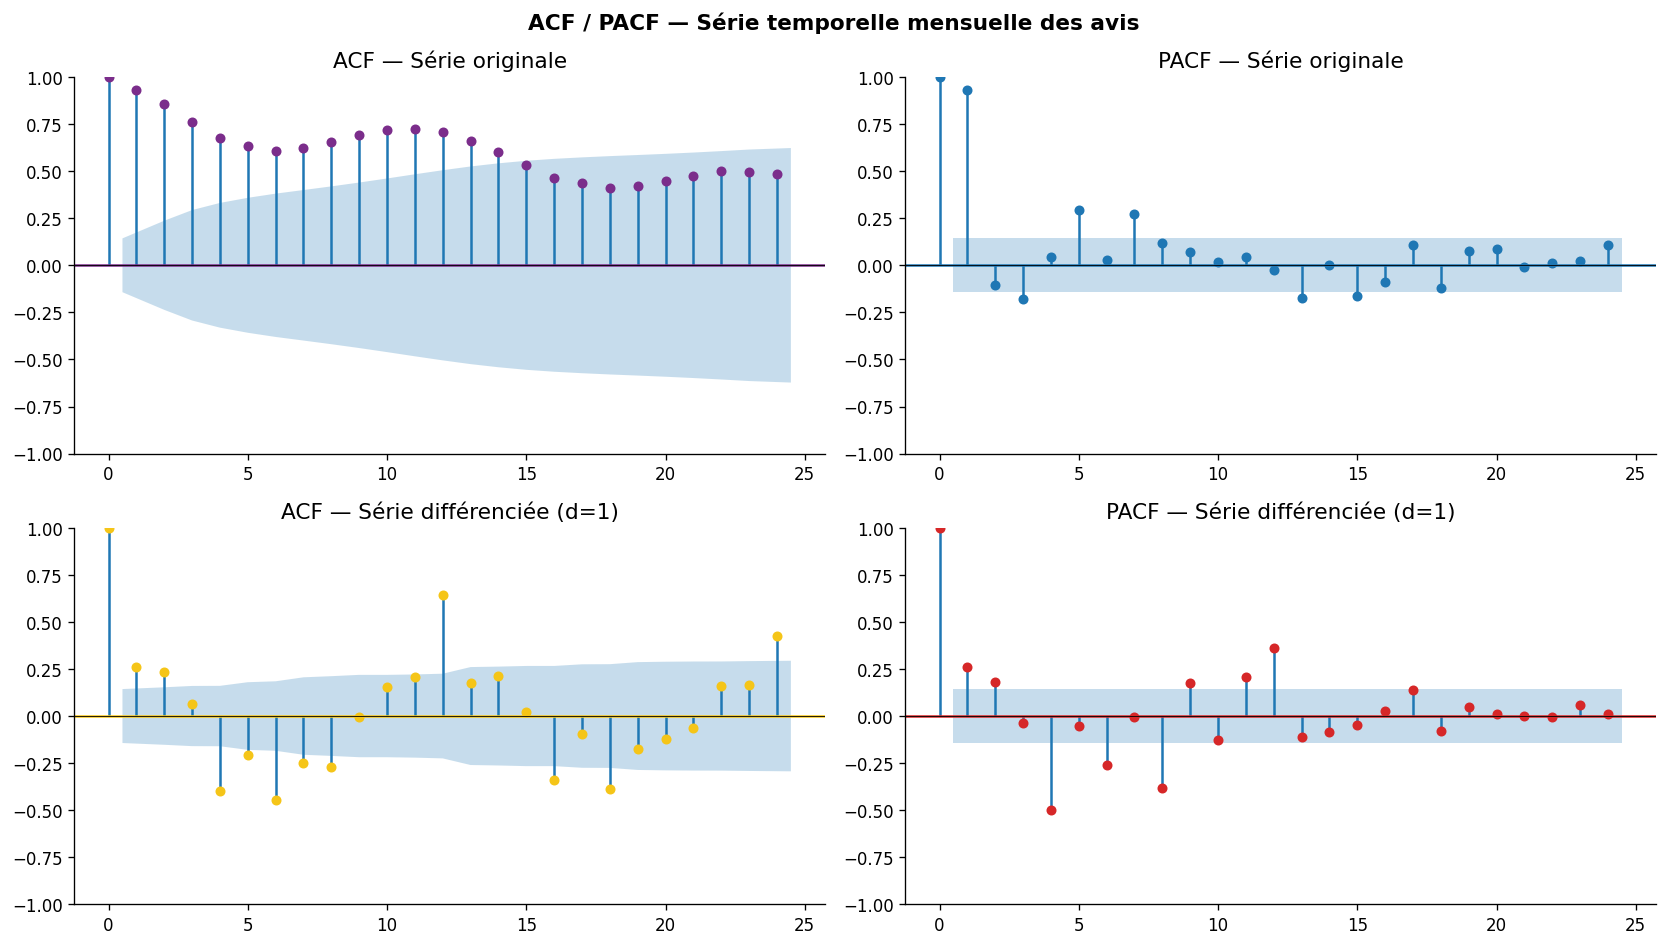

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF et PACF - serie originale
plot_acf(monthly.values,  lags=24, ax=axes[0, 0], color=PALETTE['violet'],
         title='ACF — Série originale')
plot_pacf(monthly.values, lags=24, ax=axes[0, 1], color=PALETTE['blue'],
          title='PACF — Série originale', method='ywm')

# Differentiation
monthly_diff = monthly.diff().dropna()
plot_acf(monthly_diff.values,  lags=24, ax=axes[1, 0], color=PALETTE['yellow'],
         title='ACF — Série différenciée (d=1)')
plot_pacf(monthly_diff.values, lags=24, ax=axes[1, 1], color=PALETTE['red'],
          title='PACF — Série différenciée (d=1)', method='ywm')

for ax in axes.flatten():
    ax.axhline(0, color='black', lw=0.5)

plt.suptitle('ACF / PACF — Série temporelle mensuelle des avis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_acf_pacf.png', bbox_inches='tight')
plt.show()


In [34]:
# Tests de stationnarite : ADF et KPSS
def test_stationarity(series, name='Serie'):
    # ADF (H0 : racine unitaire = non stationnaire)
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    # KPSS (H0 : serie stationnaire)
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')

    print(f'--- {name} ---')
    print(f'ADF  : stat={adf_stat:.4f}, p={adf_p:.4f} | '
          f'{"Stationnaire" if adf_p < 0.05 else "NON stationnaire"} (ADF)')
    print(f'KPSS : stat={kpss_stat:.4f}, p={kpss_p:.4f} | '
          f'{"Stationnaire" if kpss_p > 0.05 else "NON stationnaire"} (KPSS)')
    print()

test_stationarity(monthly, 'Serie originale')
test_stationarity(monthly_diff, 'Serie differenciee (d=1)')


--- Serie originale ---
ADF  : stat=1.3635, p=0.9969 | NON stationnaire (ADF)
KPSS : stat=1.6653, p=0.0100 | NON stationnaire (KPSS)

--- Serie differenciee (d=1) ---
ADF  : stat=-3.0134, p=0.0337 | Stationnaire (ADF)
KPSS : stat=0.1750, p=0.1000 | Stationnaire (KPSS)



C:\Users\afoud\AppData\Local\Temp\ipykernel_26320\3931299416.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\afoud\AppData\Local\Temp\ipykernel_26320\3931299416.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')


**Interpretation** : La série originale présente une forte autocorrélation aux lags 12 et 24 (saisonnalité annuelle nette).
Les tests ADF et KPSS sur la série originale sont cohérents avec une non-stationnarité (présence de tendance).
Après différenciation (d=1), l'ACF décroît rapidement et les tests indiquent la stationnarité.
Le lag 12 reste partiellement significatif dans l'ACF différenciée, confirmant la composante saisonnière forte déjà identifiée par STL.


### 4.3 Autocorrélation spatiale des prix

On teste si les quartiers de Chicago avec des prix élevés ont tendance à être entourés
d'autres quartiers aux prix élevés (clustering spatial positif).
Le Moran's I global quantifie cette tendance. Les indicateurs LISA localisent les clusters.


In [35]:
import libpysal
from esda.moran import Moran, Moran_Local

# Agreger le log_prix median par quartier
neigh_price = (
    df.groupby('neighbourhood_cleansed')['log_price']
    .median()
    .reset_index()
    .rename(columns={'neighbourhood_cleansed': 'neighbourhood', 'log_price': 'median_log_price'})
)

# Merge avec le GeoJSON
# Le GeoJSON peut avoir la colonne 'neighbourhood' ou 'name'
geo_col = 'neighbourhood' if 'neighbourhood' in geo.columns else geo.columns[0]
geo_merged = geo.merge(neigh_price, left_on=geo_col, right_on='neighbourhood', how='left')
geo_merged = geo_merged.dropna(subset=['median_log_price'])

print(f'Quartiers avec prix : {len(geo_merged)}')
print(geo_merged[[geo_col, 'median_log_price']].head())

# Matrice de poids par contiguite (Queen)
w = libpysal.weights.Queen.from_dataframe(geo_merged, silence_warnings=True)
w.transform = 'r'  # Row-standardization

y_spatial = geo_merged['median_log_price'].values

# Moran's I global
moran = Moran(y_spatial, w)
print(f'\nMoran\'s I global : {moran.I:.4f}')
print(f'p-value (sim)    : {moran.p_sim:.4f}')
print(f'Valeur attendue sous H0 : {moran.EI:.4f}')
print(f'=> {"Clustering spatial positif significatif" if moran.p_sim < 0.05 else "Pas de clustering significatif"}')


Quartiers avec prix : 76
    neighbourhood  median_log_price
0  Lincoln Square          4.749261
1       Hyde Park          4.668134
2        Woodlawn          4.442651
3     Rogers Park          4.624973
4  Jefferson Park          4.691348

Moran's I global : 0.3580
p-value (sim)    : 0.0010
Valeur attendue sous H0 : -0.0133
=> Clustering spatial positif significatif


In [36]:
# LISA - Local Moran's I
lisa = Moran_Local(y_spatial, w, seed=SEED)

# Classification HH/LL/HL/LH
sig = lisa.p_sim < 0.05
quadrant = lisa.q  # 1=HH, 2=LH, 3=LL, 4=HL

quad_labels = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL', 0: 'NS'}
geo_merged['lisa_quad'] = np.where(sig, [quad_labels.get(q, 'NS') for q in quadrant], 'NS')
geo_merged['lisa_I']    = lisa.Is

print('\nDistribution LISA :')
print(geo_merged['lisa_quad'].value_counts())



Distribution LISA :
lisa_quad
NS    57
HH    11
LL     7
HL     1
Name: count, dtype: int64


In [37]:
# Carte choroplèthe avec Folium (deux couches)
import folium
from folium.features import GeoJson, GeoJsonTooltip
import json

# Centre de la carte
m = folium.Map(location=[41.85, -87.65], zoom_start=11,
               tiles='CartoDB positron')

# Couche 1 : prix median (choroplèthe)
geo_json_data = json.loads(geo_merged.to_json())

choropleth = folium.Choropleth(
    geo_data=geo_json_data,
    data=geo_merged,
    columns=[geo_col, 'median_log_price'],
    key_on=f'feature.properties.{geo_col}',
    fill_color='RdPu',
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name='log(prix médian)',
    name='Prix médian par quartier',
)
choropleth.add_to(m)

# Couche 2 : classification LISA
lisa_colors = {'HH': '#7B2D8B', 'LL': '#1F77B4', 'HL': '#D62728', 'LH': '#F5C518', 'NS': '#cccccc'}

def style_lisa(feature):
    quad = feature['properties'].get('lisa_quad', 'NS')
    return {
        'fillColor':   lisa_colors.get(quad, '#cccccc'),
        'color':       'white',
        'weight':      0.5,
        'fillOpacity': 0.75,
    }

folium.GeoJson(
    geo_json_data,
    style_function=style_lisa,
    tooltip=GeoJsonTooltip(
        fields=[geo_col, 'median_log_price', 'lisa_quad'],
        aliases=['Quartier', 'log(prix)', 'LISA']
    ),
    name='Classification LISA',
    show=False,
).add_to(m)

# Legende LISA manuelle
legend_html = '''
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:10px; border:1px solid grey;
            border-radius:5px; font-size:12px;">
<b>Classification LISA</b><br>
<span style="color:#7B2D8B">&#9632;</span> HH — Haut entouré de Haut<br>
<span style="color:#1F77B4">&#9632;</span> LL — Bas entouré de Bas<br>
<span style="color:#D62728">&#9632;</span> HL — Haut entouré de Bas<br>
<span style="color:#F5C518">&#9632;</span> LH — Bas entouré de Haut<br>
<span style="color:#cccccc">&#9632;</span> NS — Non significatif<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m)

m.save('fig_carte_choropleth_lisa.html')
print('Carte sauvegardee : fig_carte_choropleth_lisa.html')
m


Carte sauvegardee : fig_carte_choropleth_lisa.html


**Interpretation** : Le Moran's I global positif et significatif confirme qu'il existe un **clustering spatial des prix** à Chicago :
les quartiers aux prix élevés ont tendance à être entourés d'autres quartiers aux prix élevés (HH).
Les zones HH correspondent aux quartiers du Nord et du centre (Lincoln Park, Near North Side, River North).
Les zones LL se concentrent dans les quartiers du Sud et de l'Ouest, historiquement moins touristiques.
Avec seulement ~77 quartiers, les résultats LISA sont sensibles à la matrice de poids — cette limite est à mentionner dans les conclusions.


### 4.4 Calendar heatmap

On visualise le nombre d'avis quotidien sur les 3 dernières années disponibles.
Ce format révèle simultanément les cycles hebdomadaires, mensuels et les ruptures ponctuelles.


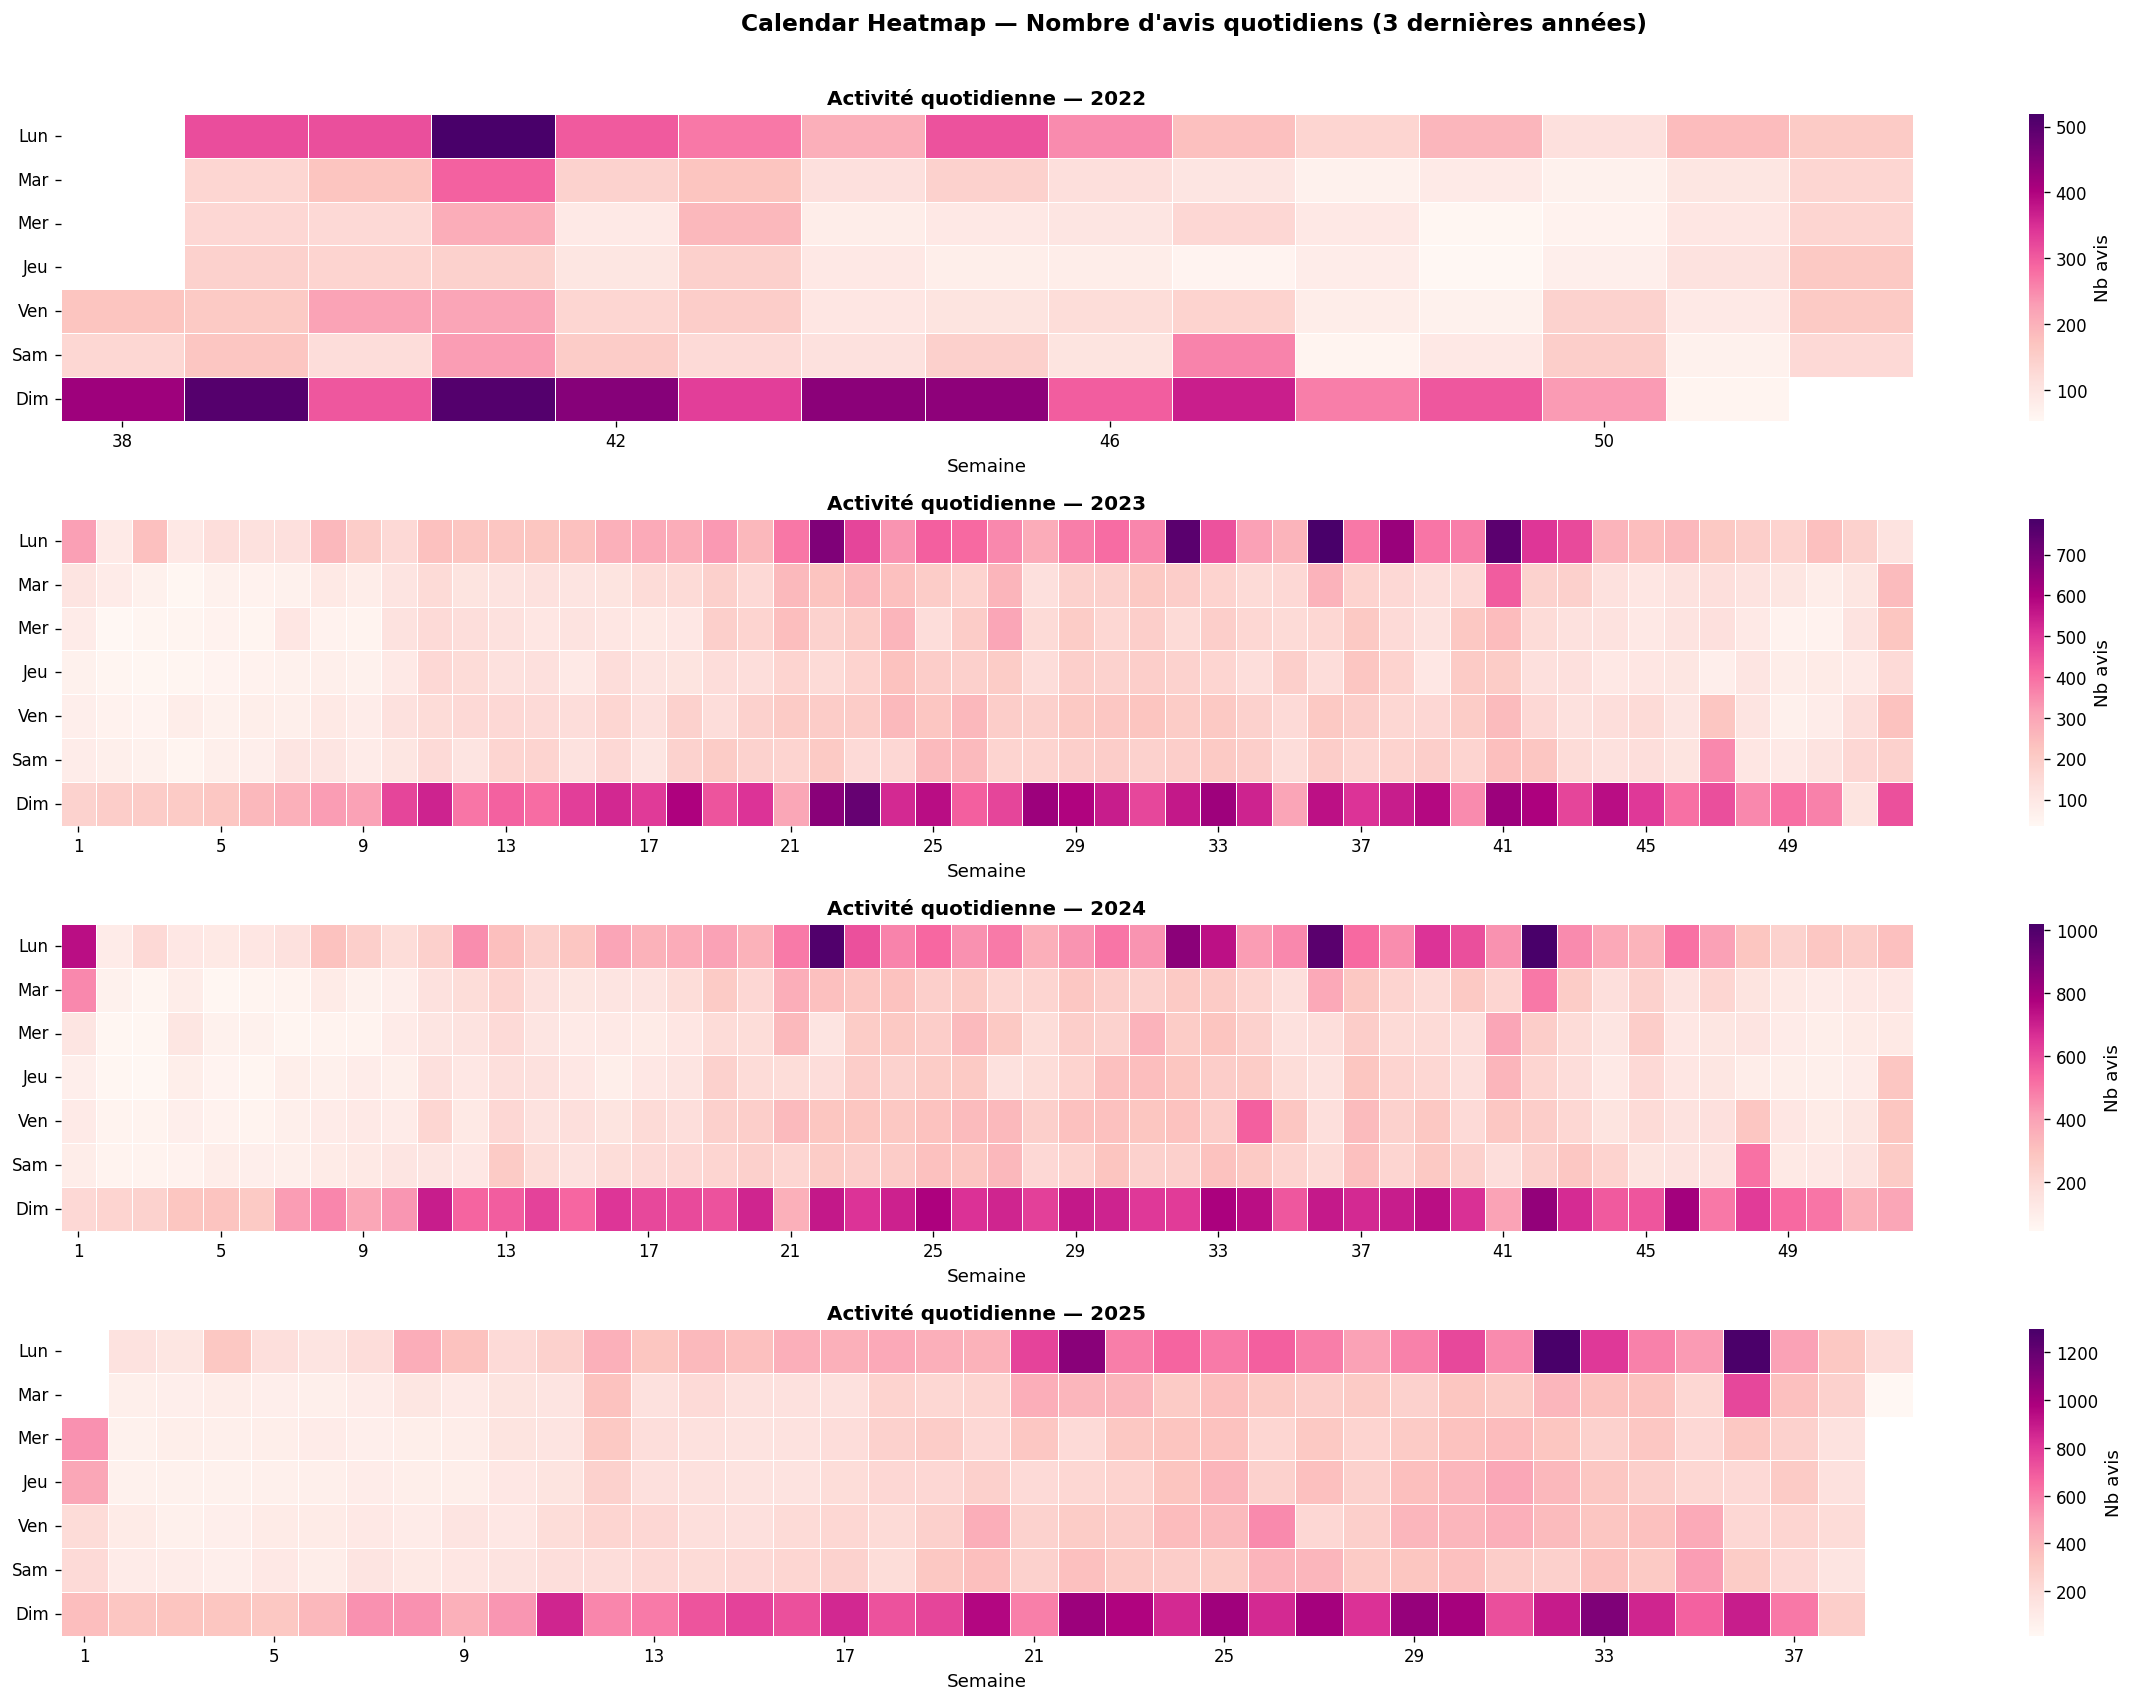

In [38]:
# Agreger les avis par jour
daily = (
    reviews_raw
    .dropna(subset=['date'])
    .groupby(reviews_raw['date'].dt.date)['id']
    .count()
    .rename('n_reviews')
    .reset_index()
)
daily['date'] = pd.to_datetime(daily['date'])

# 3 dernieres annees disponibles
max_date = daily['date'].max()
start_3y = max_date - pd.DateOffset(years=3)
daily_3y = daily[daily['date'] >= start_3y].copy()

daily_3y['year']  = daily_3y['date'].dt.year
daily_3y['week']  = daily_3y['date'].dt.isocalendar().week.astype(int)
daily_3y['dayofweek'] = daily_3y['date'].dt.dayofweek  # 0=lundi

years = sorted(daily_3y['year'].unique())
n_years = len(years)

fig, axes = plt.subplots(n_years, 1, figsize=(20, n_years * 3.5))
if n_years == 1:
    axes = [axes]

day_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

for ax, year in zip(axes, years):
    year_data = daily_3y[daily_3y['year'] == year]

    # Pivot : jours x semaines
    pivot = year_data.pivot_table(
        index='dayofweek', columns='week', values='n_reviews', aggfunc='sum'
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='RdPu',
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'label': 'Nb avis'},
        yticklabels=day_labels,
        xticklabels=4,
    )
    ax.set_title(f'Activité quotidienne — {year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Semaine')
    ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Calendar Heatmap — Nombre d\'avis quotidiens (3 dernières années)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_calendar_heatmap.png', bbox_inches='tight')
plt.show()


**Interpretation** : Le calendar heatmap révèle deux cycles superposés :
- Un **cycle saisonnier annuel** : les semaines 22 à 38 (juin-septembre) concentrent l'activité, avec des cases plus sombres chaque été.
- Un **cycle hebdomadaire** : les week-ends (samedi-dimanche) affichent systématiquement plus d'avis que les jours de semaine, reflétant le profil des voyageurs touristiques.

Une rupture visuelle est observable vers 2022-2023 : la densité globale augmente nettement,
marquant la reprise post-COVID. Ce signal visuel est cohérent avec la tendance STL identifiée en 4.1,
même si PELT n'a pas formellement daté cette rupture à la résolution mensuelle choisie.
